# Project Canary — End-to-End Model Refresh and Capstone Evidence

**Purpose:** upload an updated `FARM HARVEST DATA.xlsx`, rebuild the farm-wide harvest-recovery and Day 35 bodyweight evidence, and export manuscript-ready and presentation-ready artifacts.

This notebook is deliberately conservative. It treats harvest cycle as the primary independence group, keeps the newest cycle locked until model selection is frozen, and never treats target/interpolated bodyweights as observations.

## TL;DR

Run the notebook from top to bottom. The default `balanced` profile compares transparent baselines, regularized regression, tree ensembles, XGBoost, LightGBM and CatBoost under nested whole-cycle LOGO-CV. It then generates EDA, top-five tables, daily and checkpoint performance, uncertainty, SHAP, capstone notes and a downloadable ZIP.

**Status boundary:** outputs are research/shadow evidence. The notebook never automatically deploys a model into the owner dashboard.

## 1. Setup and reproducibility

In [1]:
from pathlib import Path
import json, os, subprocess, sys
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jourdandgo/Project_Canary_Capstone.git"
REPO_REF = os.getenv("CANARY_REPO_REF", "main")  # Pin to a reviewed commit for formal submission.
if IN_COLAB:
    REPO_ROOT = Path("/content/Project_Canary_Capstone")
    if not REPO_ROOT.exists():
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", REPO_REF, REPO_URL, str(REPO_ROOT)])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_ROOT / "requirements-colab.txt")])
    os.chdir(REPO_ROOT)
else:
    REPO_ROOT = Path.cwd().resolve()
    if not (REPO_ROOT / "canary").exists():
        raise RuntimeError("Run the notebook from the canary_app/Project Canary repository root.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("Repository:", REPO_ROOT)
print("Profile dependency setup complete.")

Repository: /Users/jourdan.go/Downloads/PROJECT CANARY/canary_app
Profile dependency setup complete.


### Configuration
The newest recorded cycle is locked automatically. Set `AUDIT_CYCLE` explicitly only when the team has frozen a different audit cycle.

In [2]:
RUN_PROFILE = os.getenv("CANARY_RUN_PROFILE", "balanced")  # balanced | full; smoke is reserved for automated tests
AUDIT_CYCLE = os.getenv("CANARY_AUDIT_CYCLE", "latest")
FIXED_SEED = 20260812
OUTPUT_DIR = REPO_ROOT / "outputs" / "colab_capstone_refresh_latest"
if IN_COLAB:
    WORKBOOK_PATH = Path("/content/FARM HARVEST DATA.xlsx")
else:
    WORKBOOK_PATH = (REPO_ROOT.parent / "FARM HARVEST DATA.xlsx").resolve()
print({"run_profile": RUN_PROFILE, "audit_cycle": AUDIT_CYCLE, "seed": FIXED_SEED, "output": str(OUTPUT_DIR)})

{'run_profile': 'balanced', 'audit_cycle': 'latest', 'seed': 20260812, 'output': '/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest'}


### Upload the authoritative workbook

In [3]:
if IN_COLAB and not WORKBOOK_PATH.exists():
    from google.colab import files
    uploaded = files.upload()
    selected = next((name for name in uploaded if name.lower().endswith(".xlsx")), None)
    if selected is None:
        raise ValueError("Upload FARM HARVEST DATA.xlsx")
    Path(selected).replace(WORKBOOK_PATH)
if not WORKBOOK_PATH.exists():
    raise FileNotFoundError(f"Workbook not found: {WORKBOOK_PATH}")
print("Authoritative workbook:", WORKBOOK_PATH)

Authoritative workbook: /Users/jourdan.go/Downloads/PROJECT CANARY/FARM HARVEST DATA.xlsx


## 2. Source and data-quality audit

In [4]:
from canary.data import load_workbook
dataset = load_workbook(WORKBOOK_PATH)
source_preview = {
    "source_rows": dataset.quality.source_rows,
    "canonical_rows": dataset.quality.canonical_rows,
    "building_cycles": int(len(dataset.cycles)),
    "harvest_cycles": int(dataset.cycles.cycle_id.nunique()),
    "weight_measurement_days": dataset.quality.weight_measurement_days,
    "temperature_coverage_pct": dataset.quality.temperature_coverage_pct,
    "humidity_coverage_pct": dataset.quality.humidity_coverage_pct,
    "blocking_errors": list(dataset.quality.blocking_errors),
    "warnings": list(dataset.quality.warnings),
}
source_preview

/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be 

{'source_rows': 1624,
 'canonical_rows': 1624,
 'building_cycles': 34,
 'harvest_cycles': 7,
 'weight_measurement_days': 210,
 'temperature_coverage_pct': 43.47290640394089,
 'humidity_coverage_pct': 41.6256157635468,
 'blocking_errors': [],
 'warnings': ['16 building-day row(s) contain no recorded mortality or feed observation.',
  'Bodyweight is sampled rather than measured daily; the latest actual measurement is retained with its age.']}

**What this means:** critical contract failures stop the run. Warnings remain visible because unusual biology, incomplete environment, stale weights and unresolved feed units affect how strongly the results can be interpreted.

## 3. Run the end-to-end audit, EDA, training and export

In [5]:
from canary.colab_workflow import RunConfig, run_capstone_workflow
config = RunConfig(
    workbook_path=WORKBOOK_PATH,
    output_dir=OUTPUT_DIR,
    run_profile=RUN_PROFILE,
    seed=FIXED_SEED,
    audit_cycle=AUDIT_CYCLE,
)
result = run_capstone_workflow(config)
print("Completed:", result["output_dir"])
print("Export ZIP:", result["zip_path"])

/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be 

/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be 

/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


[recovery] reusing completed frozen outcome manifest


[weight] reusing completed frozen outcome manifest


/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be 

Wrote daily capstone accuracy evidence to /Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest/daily_accuracy


Completed: /Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest
Export ZIP: /Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest_EXPORT.zip


## 4. Capstone-focused EDA

In [6]:
import pandas as pd
from IPython.display import Image, display
eda_summary = pd.read_csv(OUTPUT_DIR / "eda" / "tables" / "eda_summary.csv")
display(eda_summary)

,metric,value,interpretation
0,Raw building-day rows,1624.000000,Repeated daily records are correlated observat...
1,Canonical building-day rows,1624.000000,"One canonical row per building, cycle and day ..."
2,Building-cycles,34.000000,Each building-cycle supplies one mature outcome.
3,Harvest cycles,7.000000,Harvest cycle is the primary independence grou...
4,Observed Day 35 weights,34.000000,Only actually observed Day 35 weights are supe...
5,Temperature coverage (%),43.472906,Incomplete coverage limits stable environmenta...
6,Humidity coverage (%),41.625616,Missingness is retained as evidence rather tha...


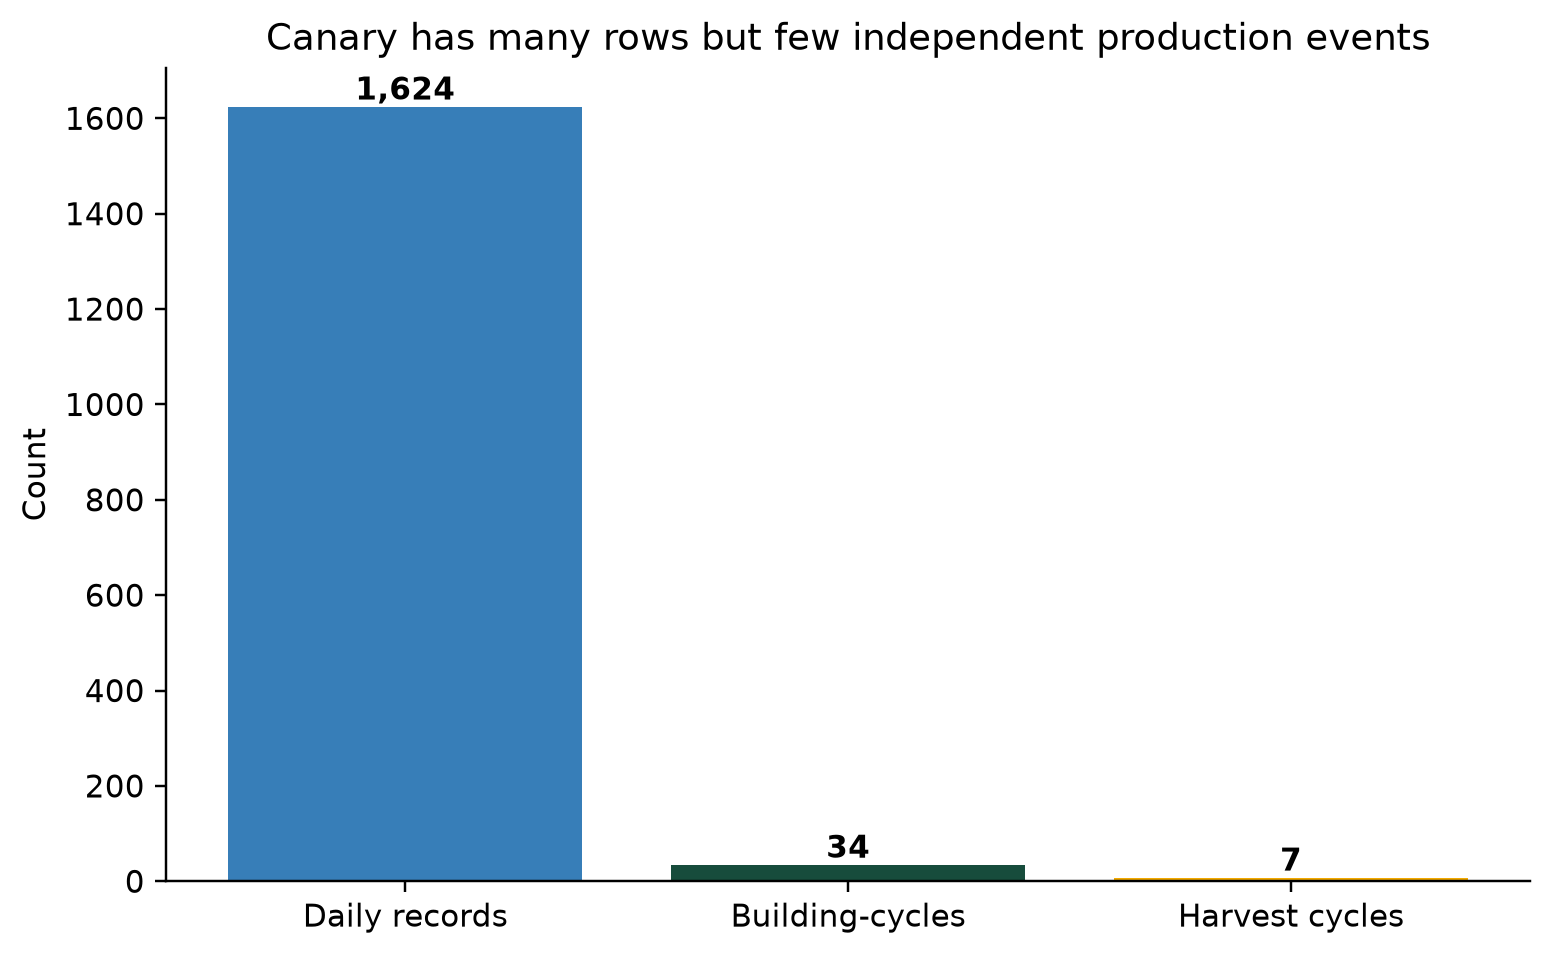

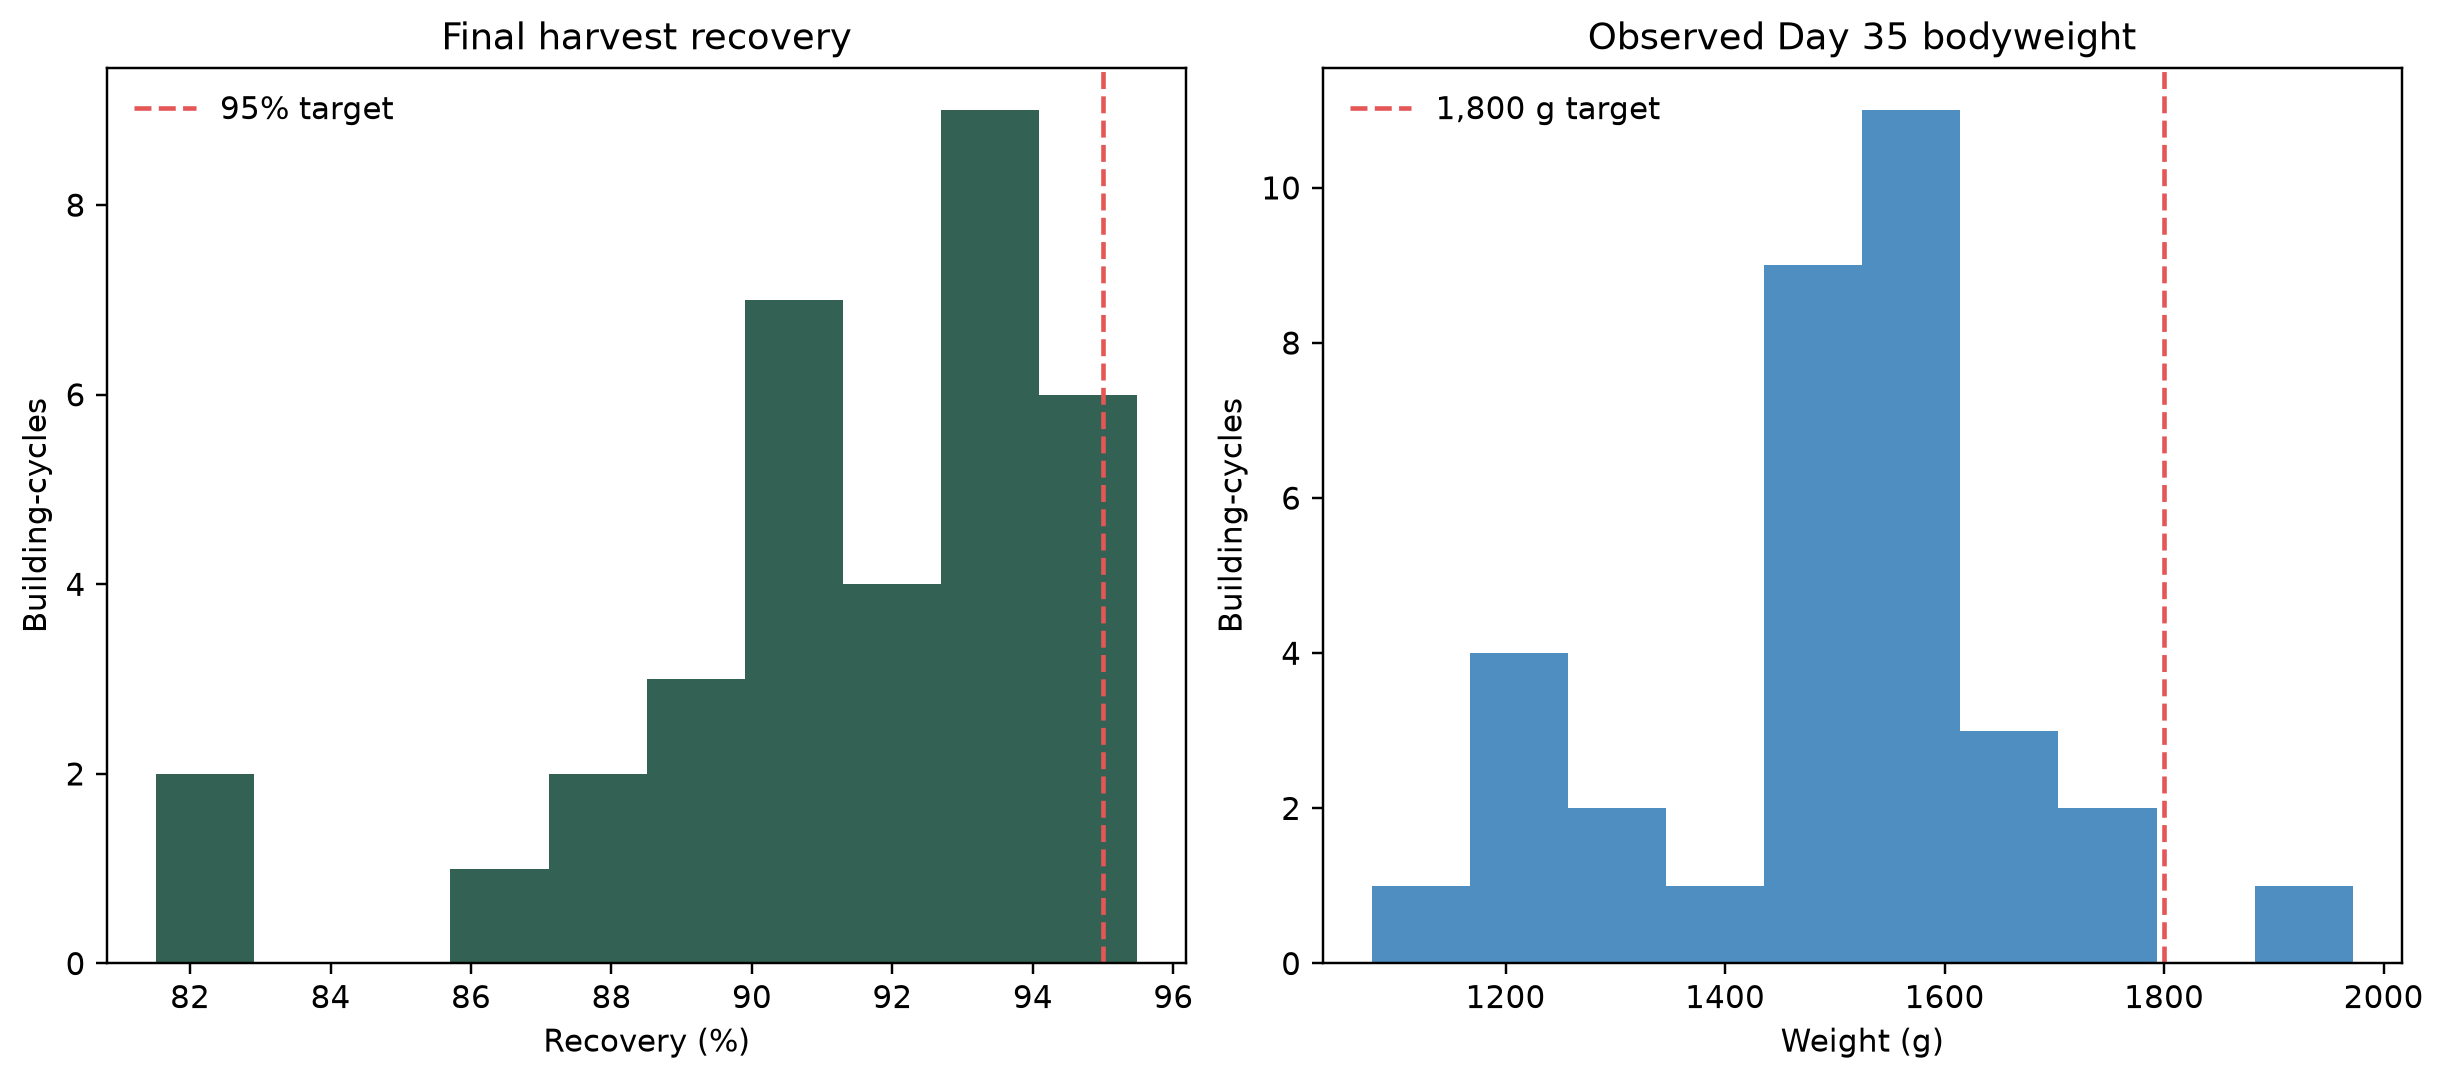

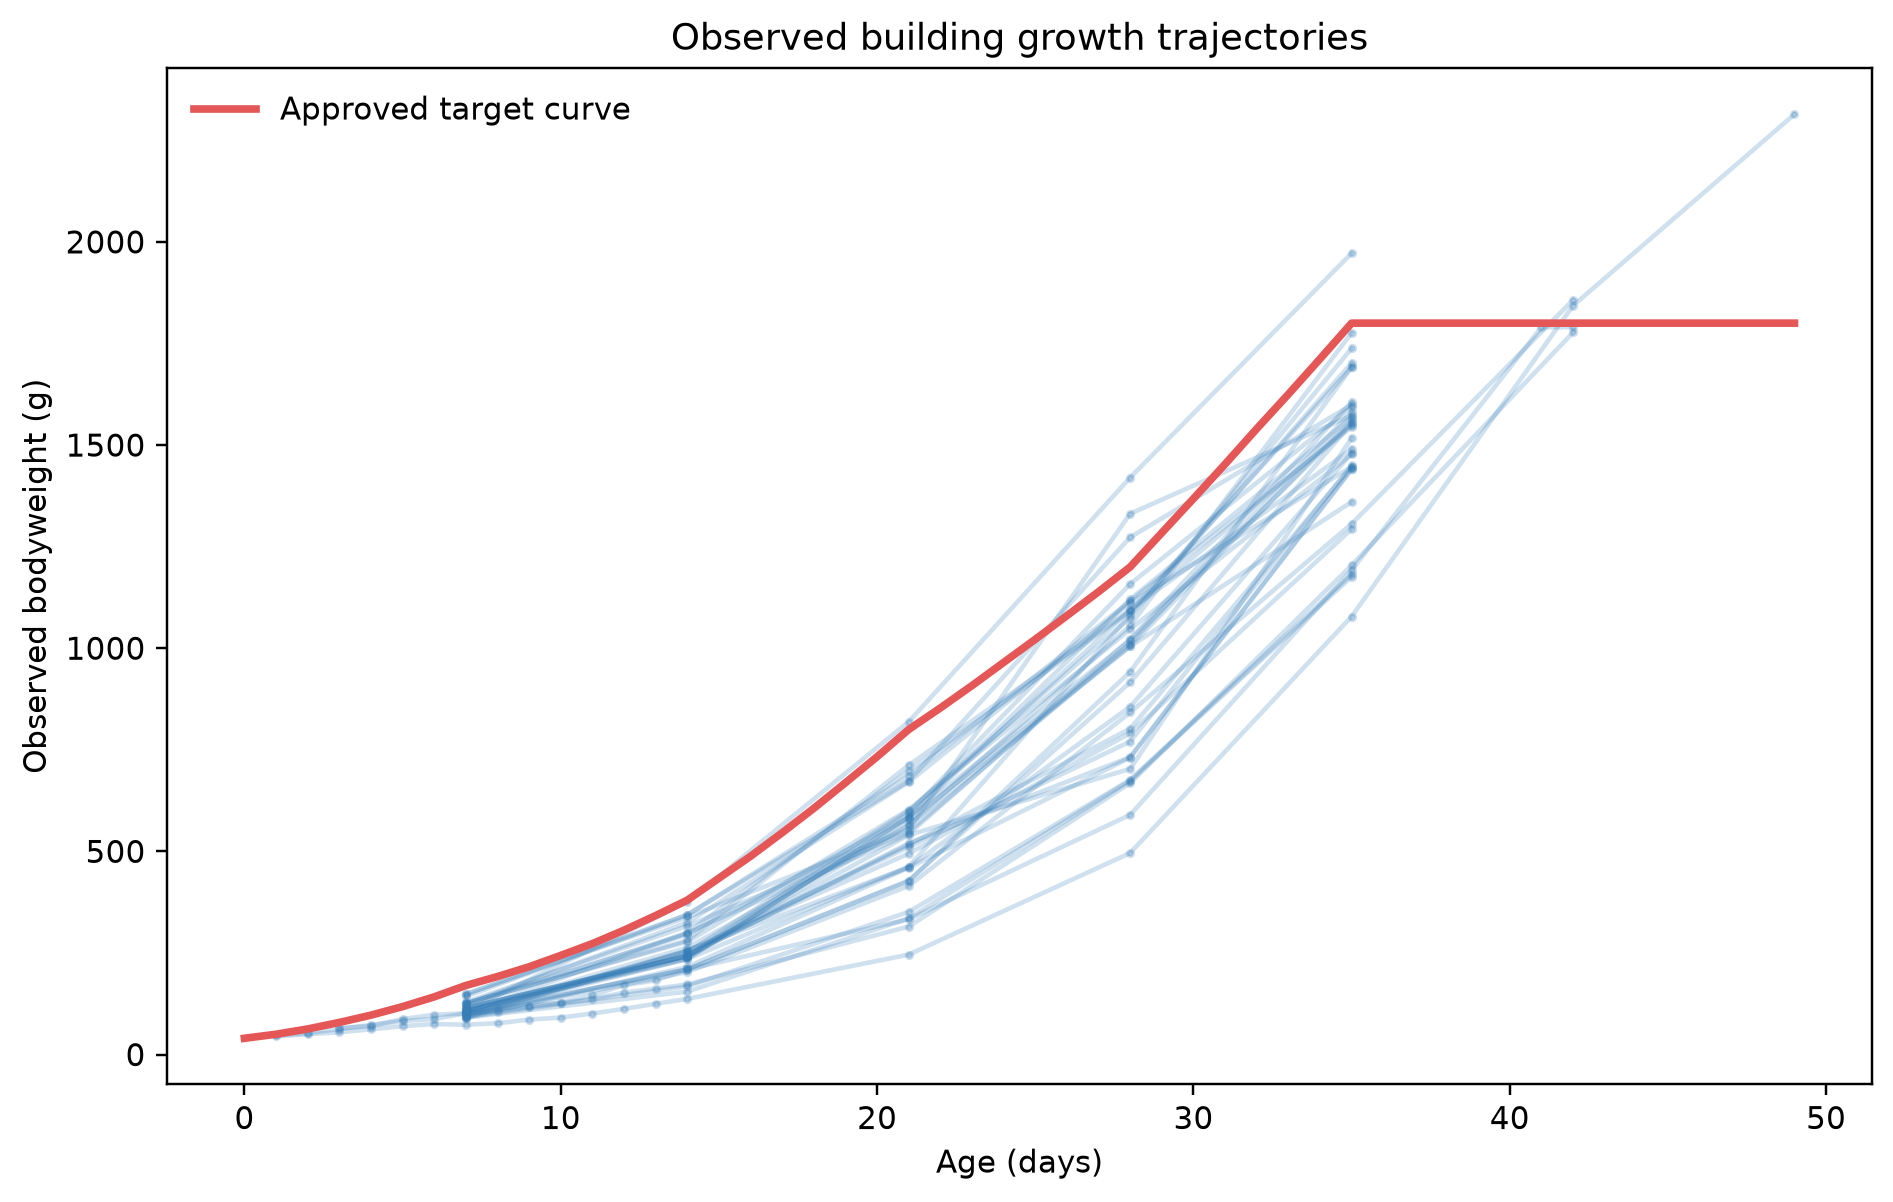

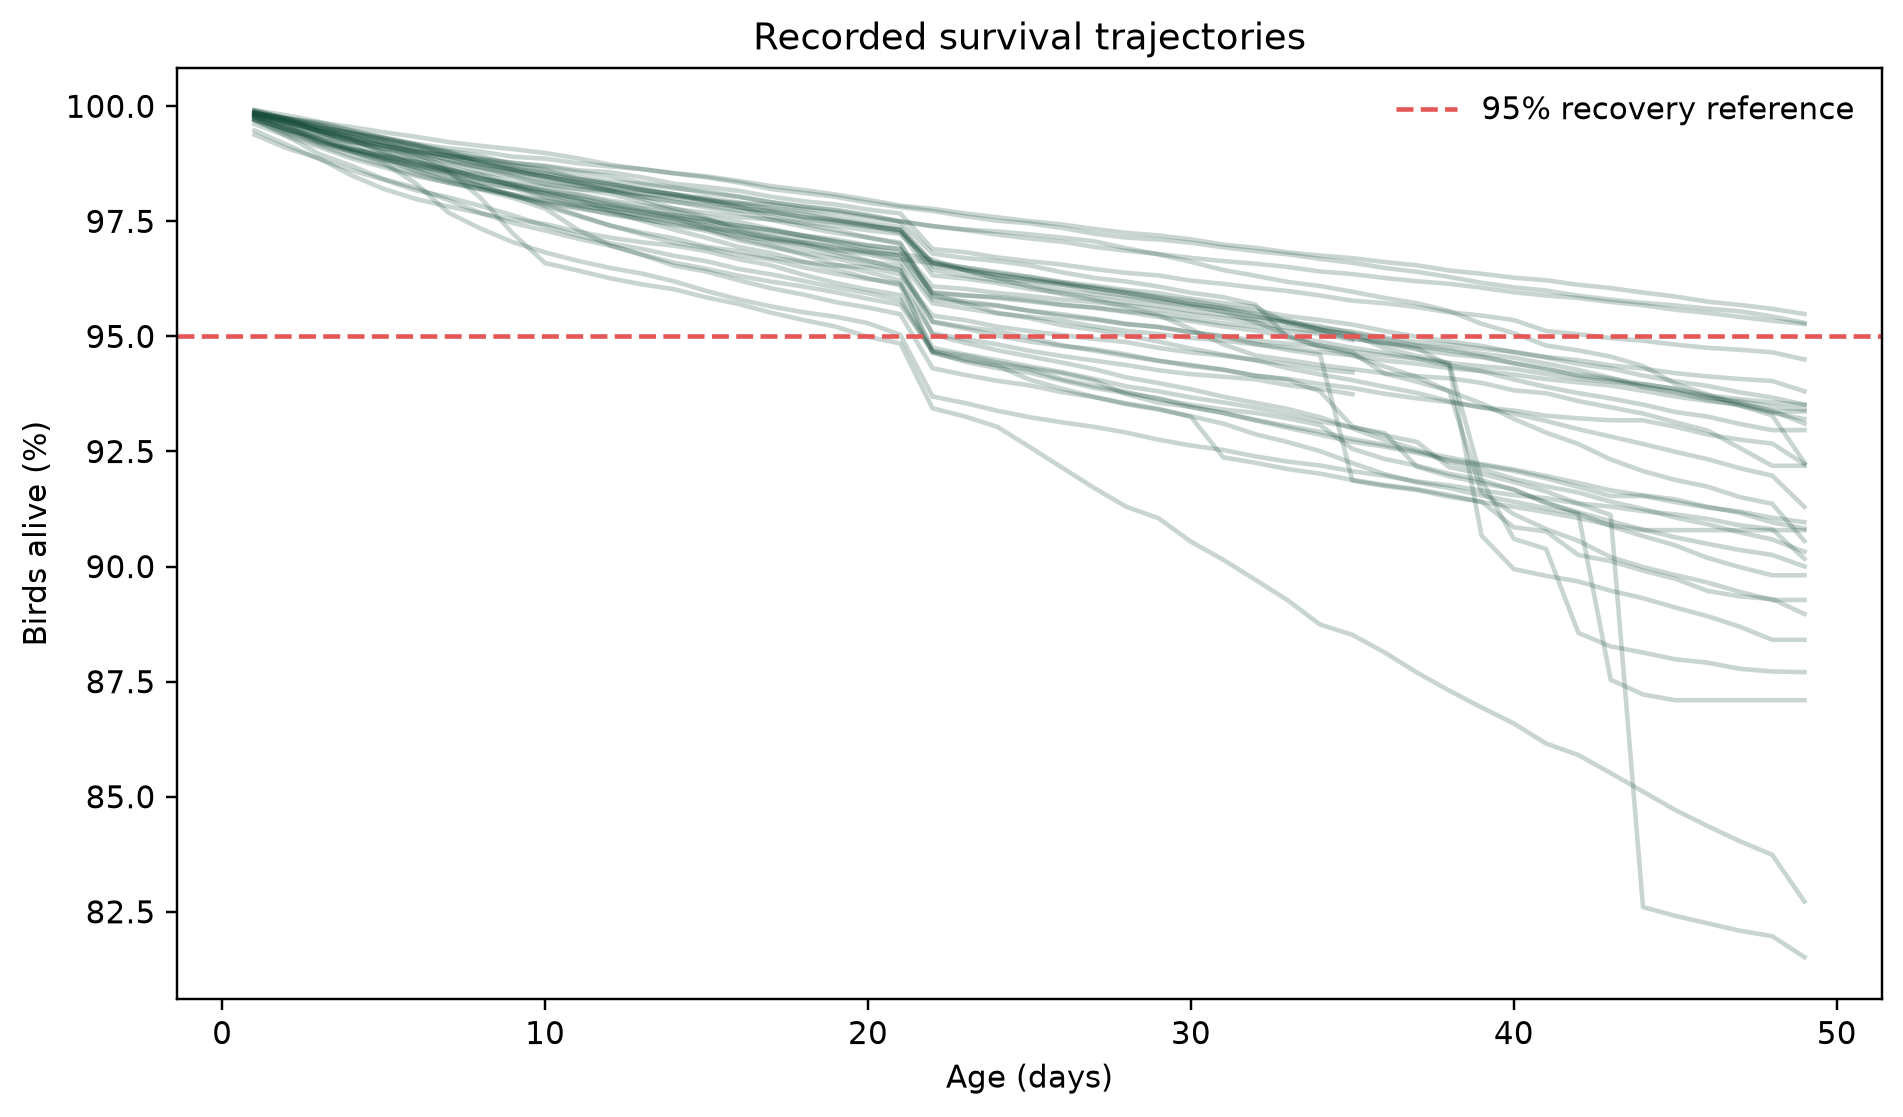

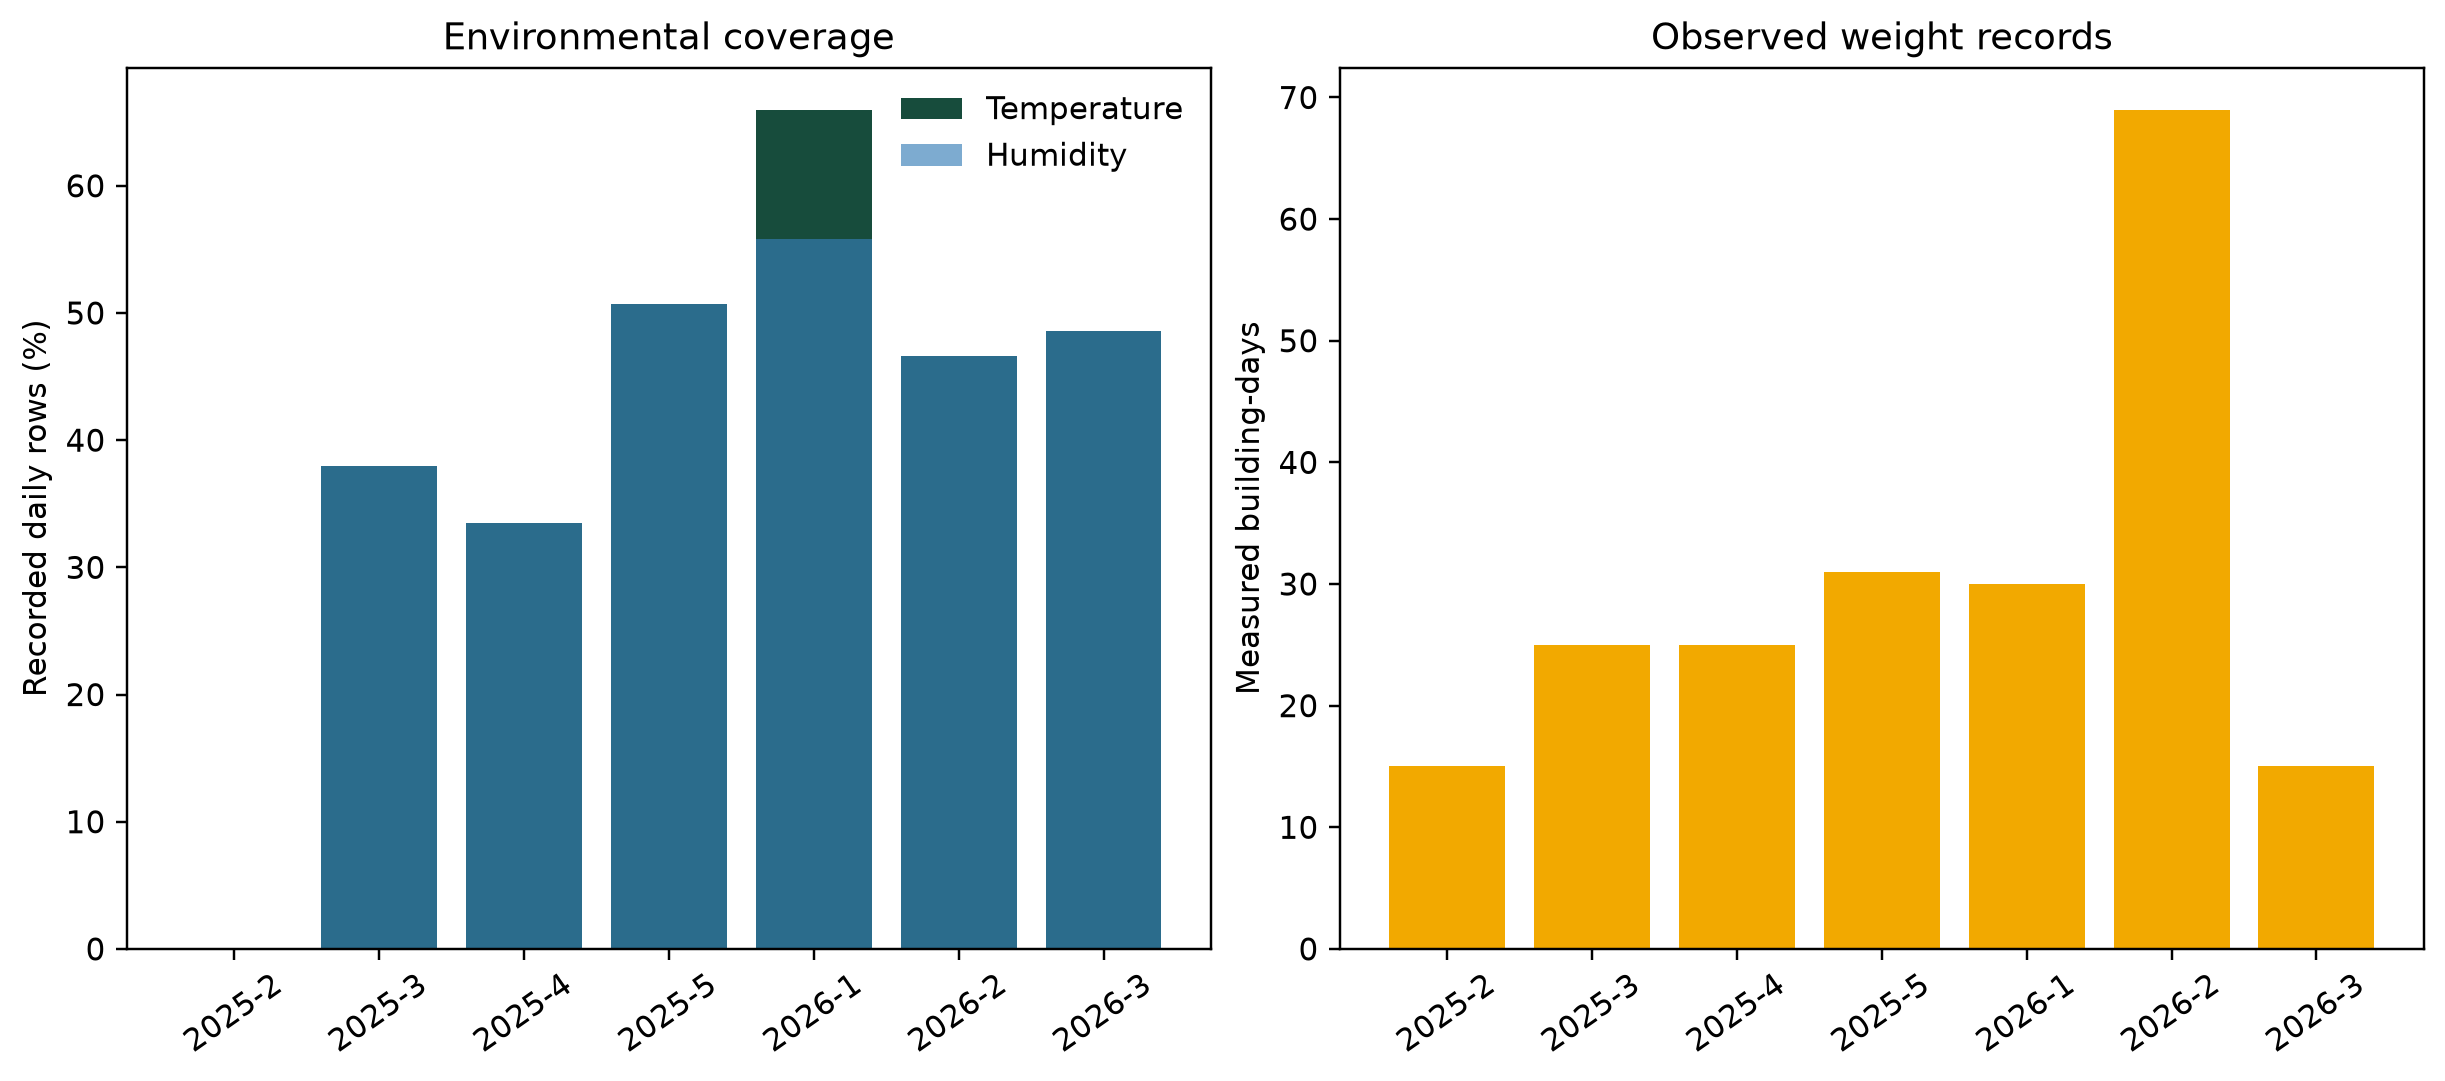

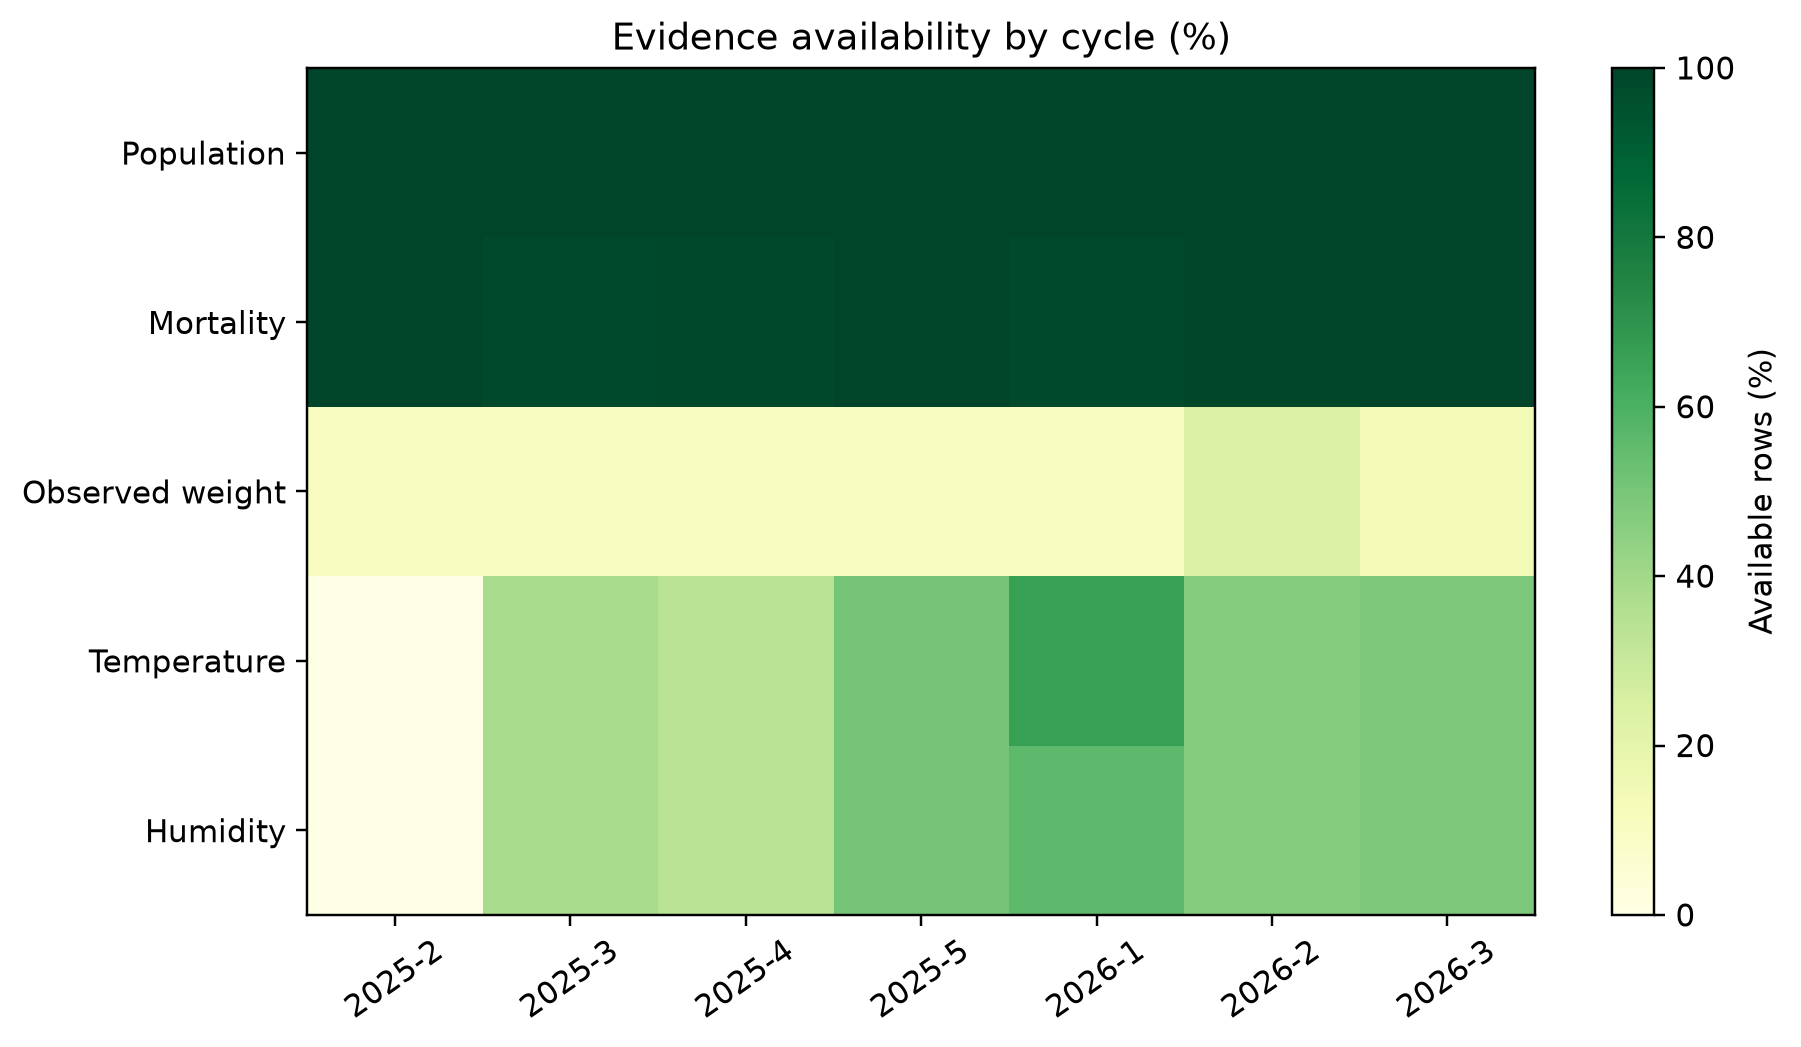

,figure,title,what_this_means
0,01_dataset_hierarchy,Dataset hierarchy,The effective validation sample is governed by...
1,02_outcome_distributions,Outcome distributions,"Target-side outcomes are imbalanced, so contin..."
2,03_weight_trajectories,Observed growth trajectories,Measurements are sparse and heterogeneous; the...
3,04_survival_trajectories,Survival trajectories,Later survival contains more endpoint informat...
4,05_target_deficit,Target deficit trajectories,"Deficit is a useful biological reference, but ..."
5,06_mortality_by_cycle,Mortality signal by cycle,Mortality patterns cluster within production c...
6,07_measurement_coverage,Measurement coverage,"Coverage differs materially by cycle, limiting..."
7,08_missingness_heatmap,Missingness by cycle,Missing evidence is structured by cycle rather...
8,09_checkpoint_availability,Checkpoint availability,"A Day 10 forecast is possible, but bodyweight ..."
9,10_descriptive_correlations,Descriptive correlations,Small-sample associations can be cycle-confoun...


In [7]:
for name in ["01_dataset_hierarchy", "02_outcome_distributions", "03_weight_trajectories", "04_survival_trajectories", "07_measurement_coverage", "08_missingness_heatmap"]:
    display(Image(filename=str(OUTPUT_DIR / "eda" / "figures" / f"{name}.png"), width=900))
display(pd.read_csv(OUTPUT_DIR / "eda" / "figure_catalog.csv"))

### Key EDA interpretation

The many daily rows provide useful trajectory evidence, but they do not create hundreds of independent production events. Building observations share feed, weather, management and timing within harvest cycles. Consequently, whole-cycle holdout validation is the defensible test of performance on a future cycle.

## 5. Model comparison and champion selection


 RECOVERY


,rank,candidate,family,cycle_macro_rmse,rmse,mae,r2,bias,worst_cycle_rmse
0,1,residual_lightgbm_peer,lightgbm,3.092,3.124,2.449,0.056,-0.036,6.091
1,2,residual_xgboost_peer,xgboost,3.092,3.124,2.449,0.056,-0.036,6.091
2,3,age_band_remaining_loss,baseline,3.092,3.124,2.449,0.056,-0.036,6.091
3,4,remaining_random_forest_peer,random_forest,3.141,3.282,2.461,-0.042,0.400,7.031
4,5,residual_catboost_peer,catboost,3.164,3.307,2.478,-0.058,0.476,6.994


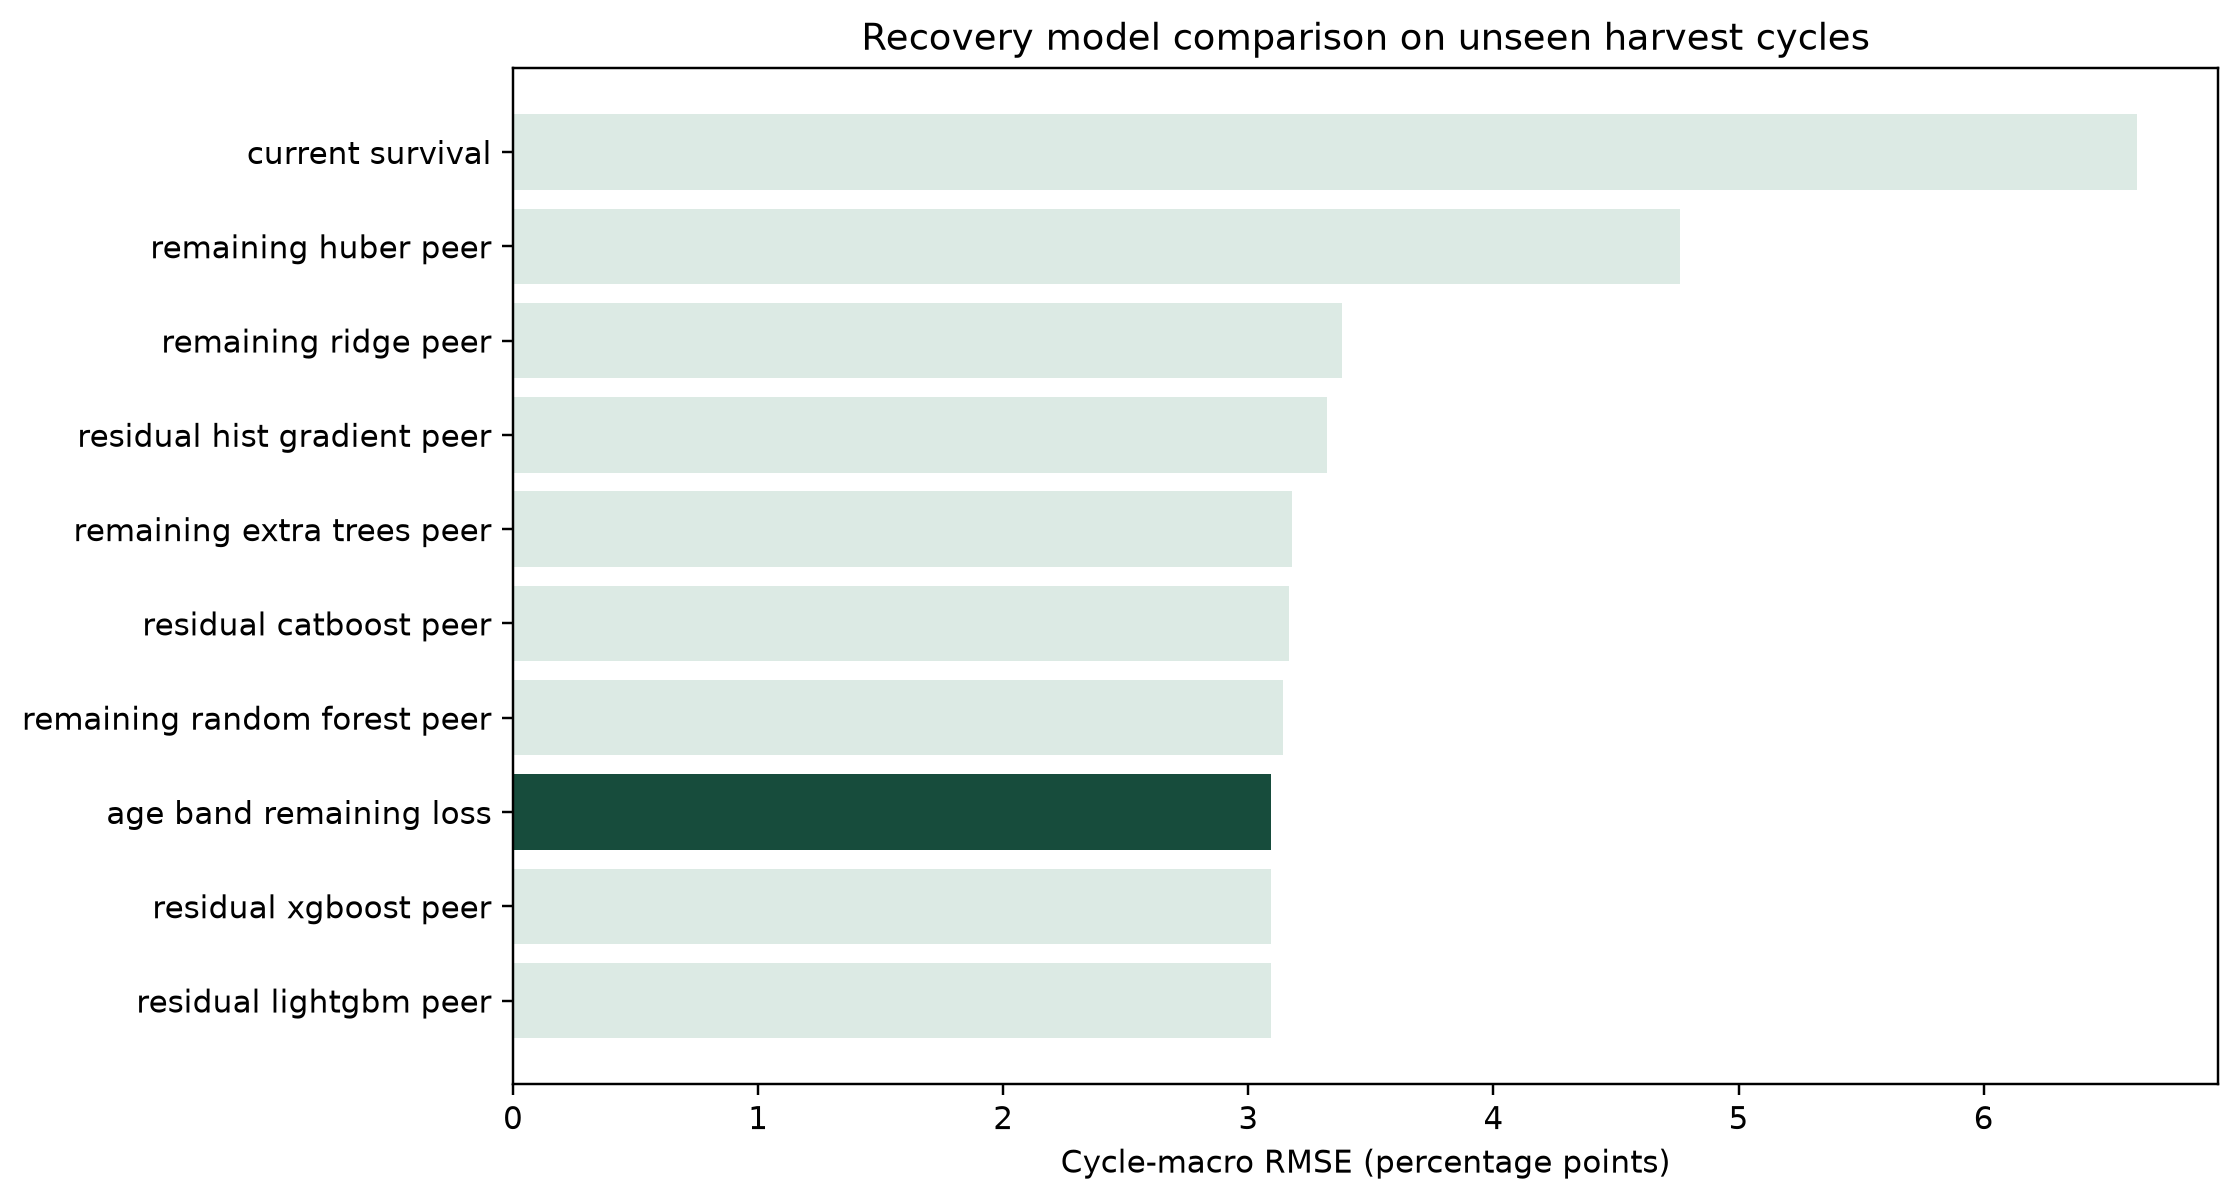


 BODYWEIGHT


,rank,candidate,family,cycle_macro_rmse,rmse,mae,r2,bias,worst_cycle_rmse
0,1,historical_remaining_gain,baseline,149.908,163.909,127.121,0.310,-0.646,203.137
1,2,residual_xgboost_peer,xgboost,152.301,167.247,130.055,0.282,-2.615,210.592
2,3,residual_catboost_peer,catboost,153.336,169.469,131.415,0.263,11.462,208.965
3,4,residual_lightgbm_peer,lightgbm,155.186,171.158,133.114,0.248,0.653,212.242
4,5,residual_hist_gradient_peer,hist_gradient_boosting,155.211,170.622,133.209,0.252,0.753,213.090


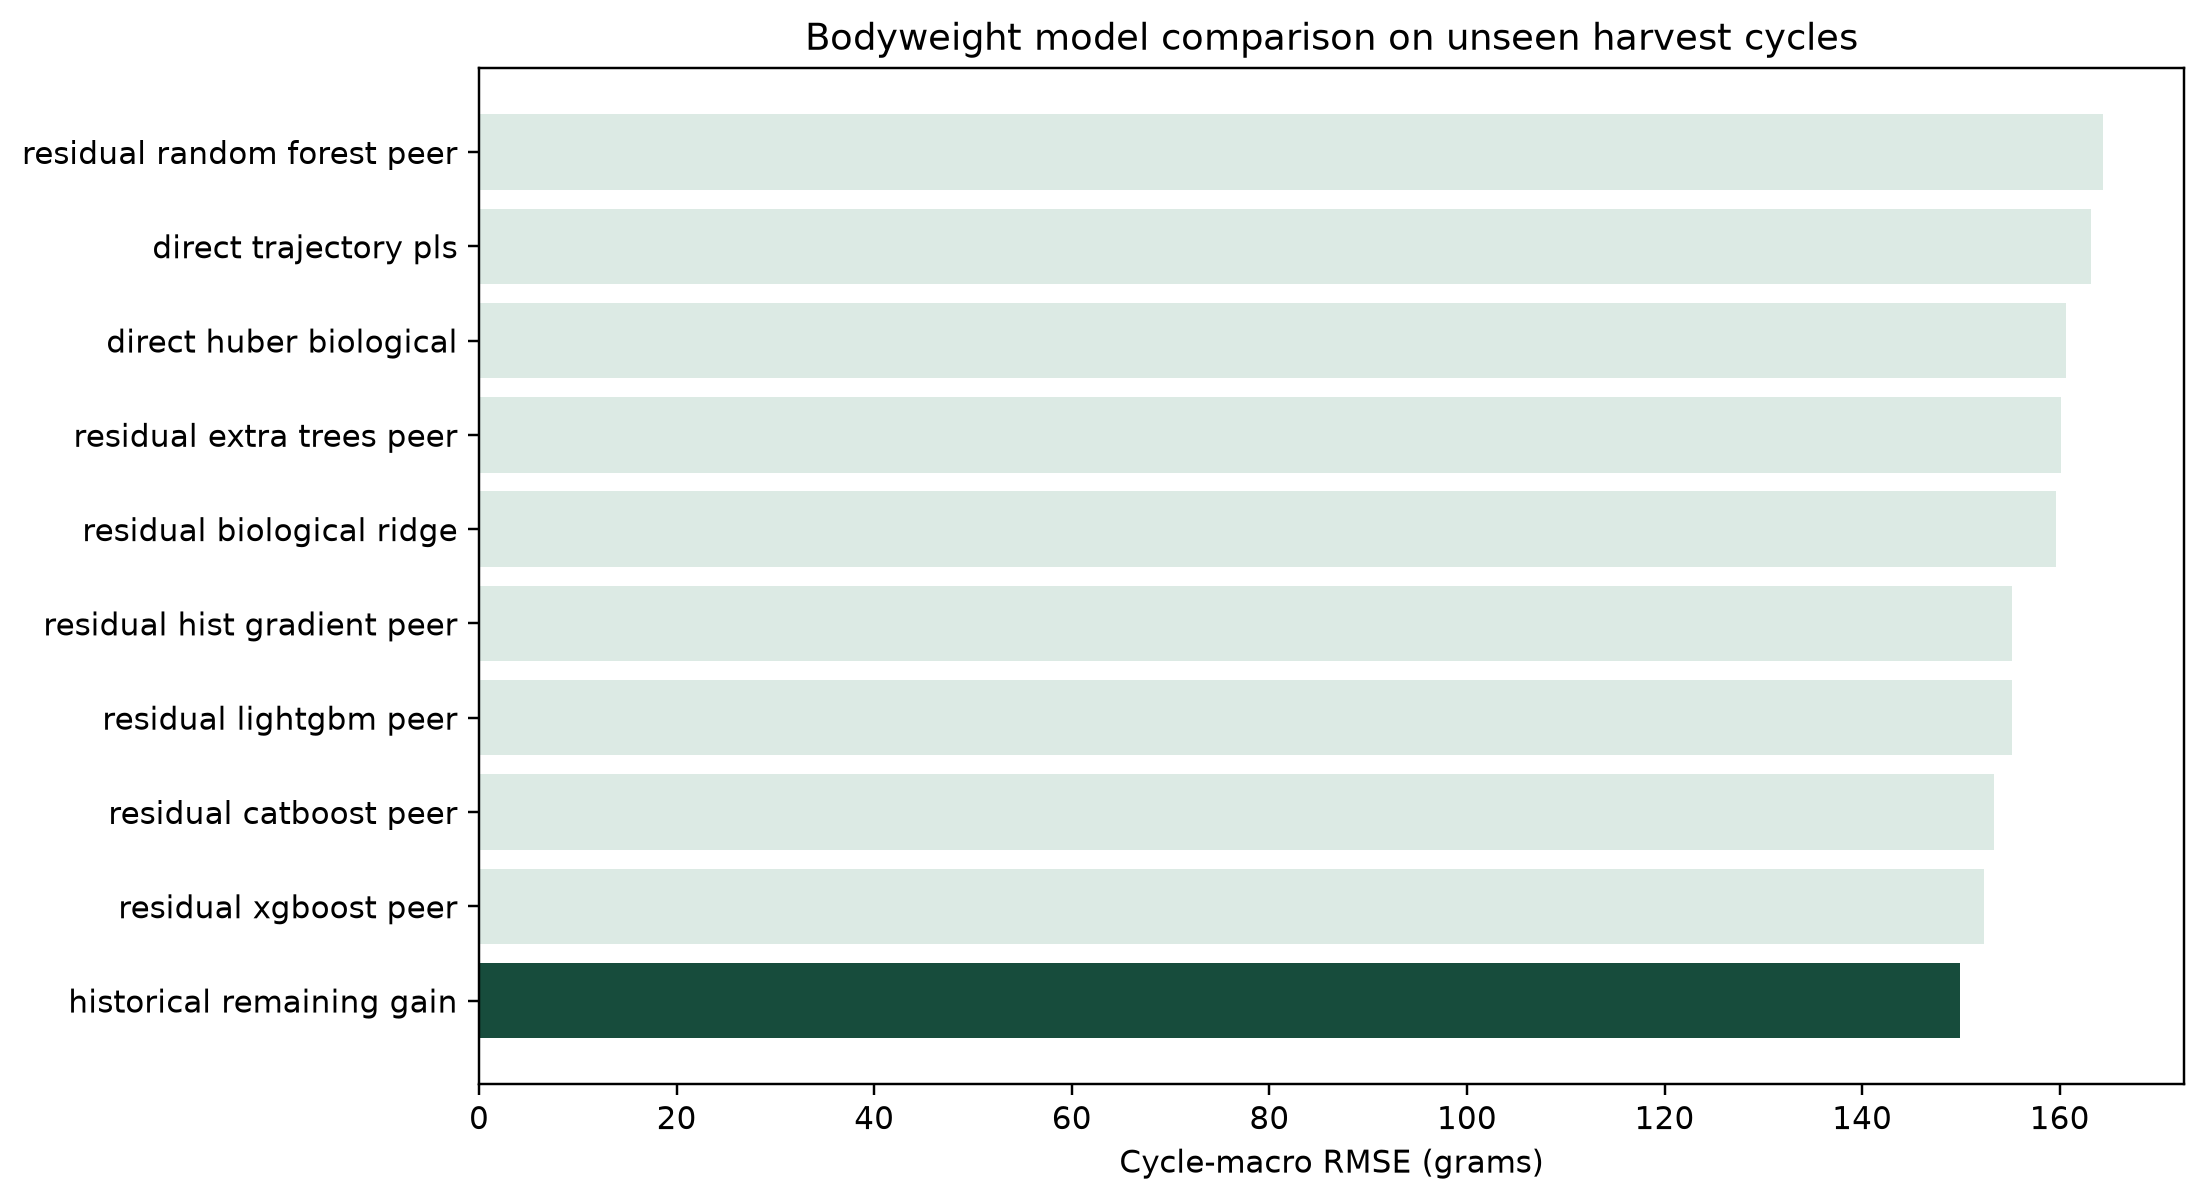

In [8]:
model_tables = {}
for outcome in ["recovery", "bodyweight"]:
    table = pd.read_csv(OUTPUT_DIR / outcome / "top_five_models.csv").sort_values("rank")
    model_tables[outcome] = table
    print("\n", outcome.upper())
    display(table[["rank", "candidate", "family", "cycle_macro_rmse", "rmse", "mae", "r2", "bias", "worst_cycle_rmse"]].round(3))
    display(Image(filename=str(OUTPUT_DIR / "capstone_assets" / outcome / "model_comparison.png"), width=850))

**Selection rule:** cycle-macro RMSE is primary. The one-standard-error rule selects the simplest statistically competitive candidate. A slightly lower-error learned model can remain a shadow model when its gain is too small, unstable, biased or poorly calibrated.

## 6. Actual versus predicted and residual diagnostics

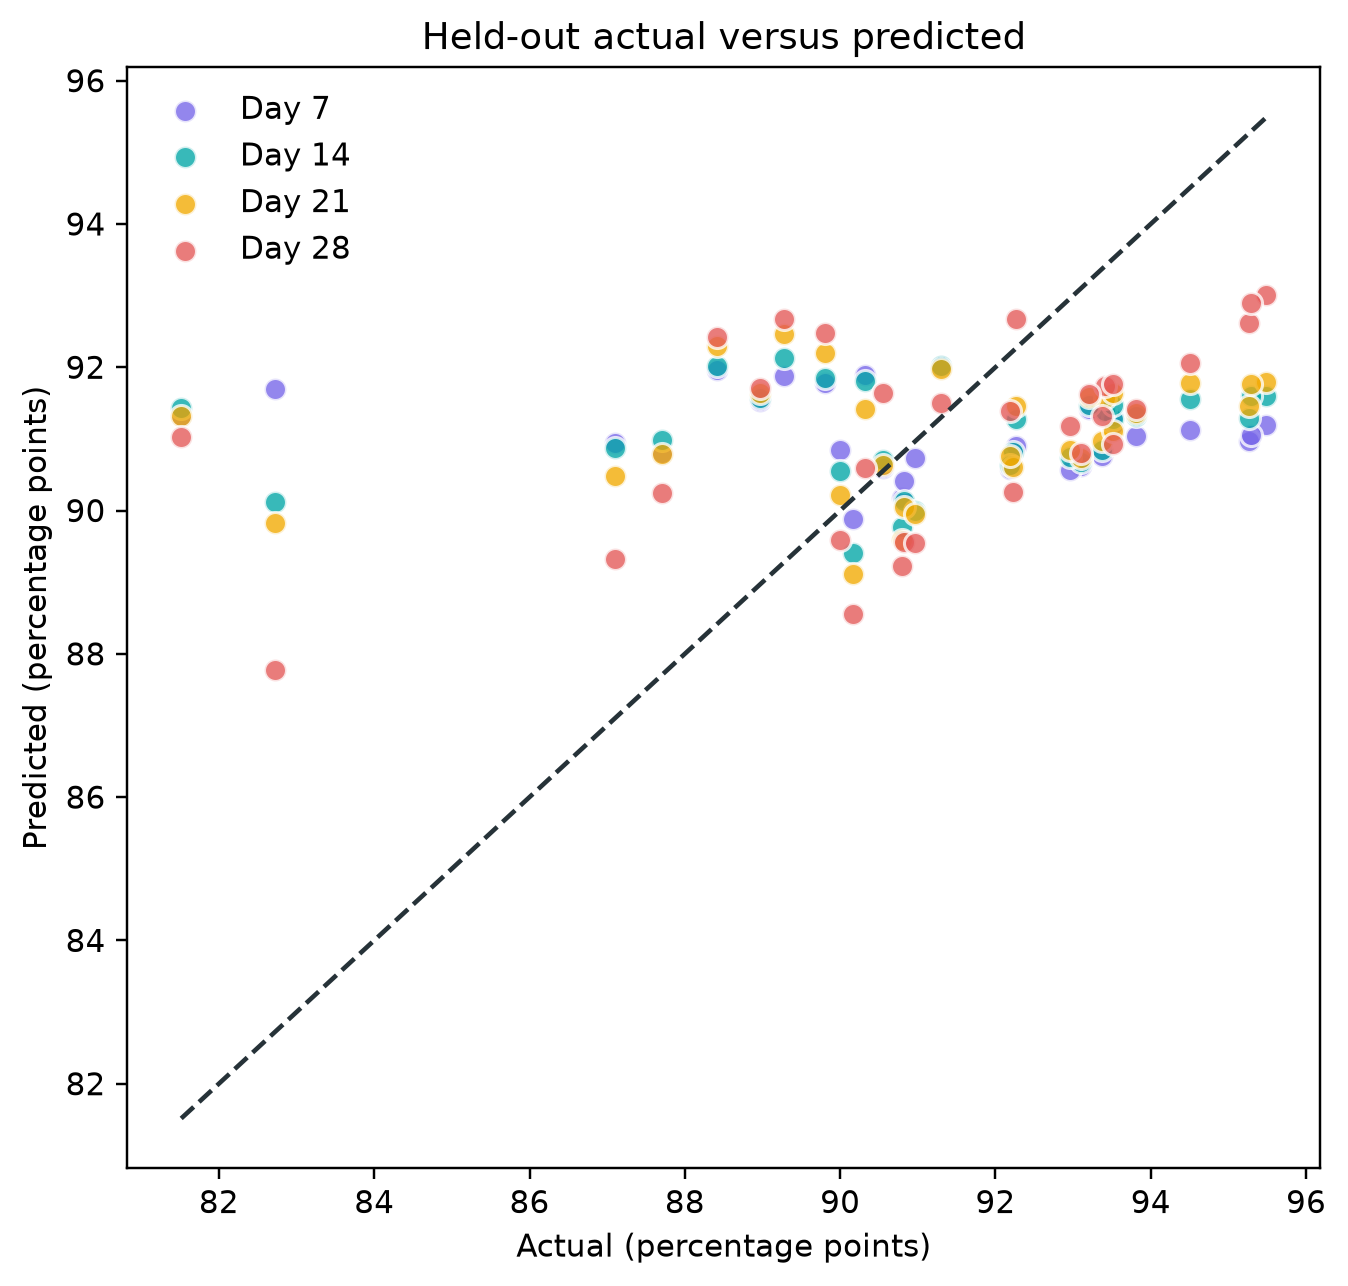

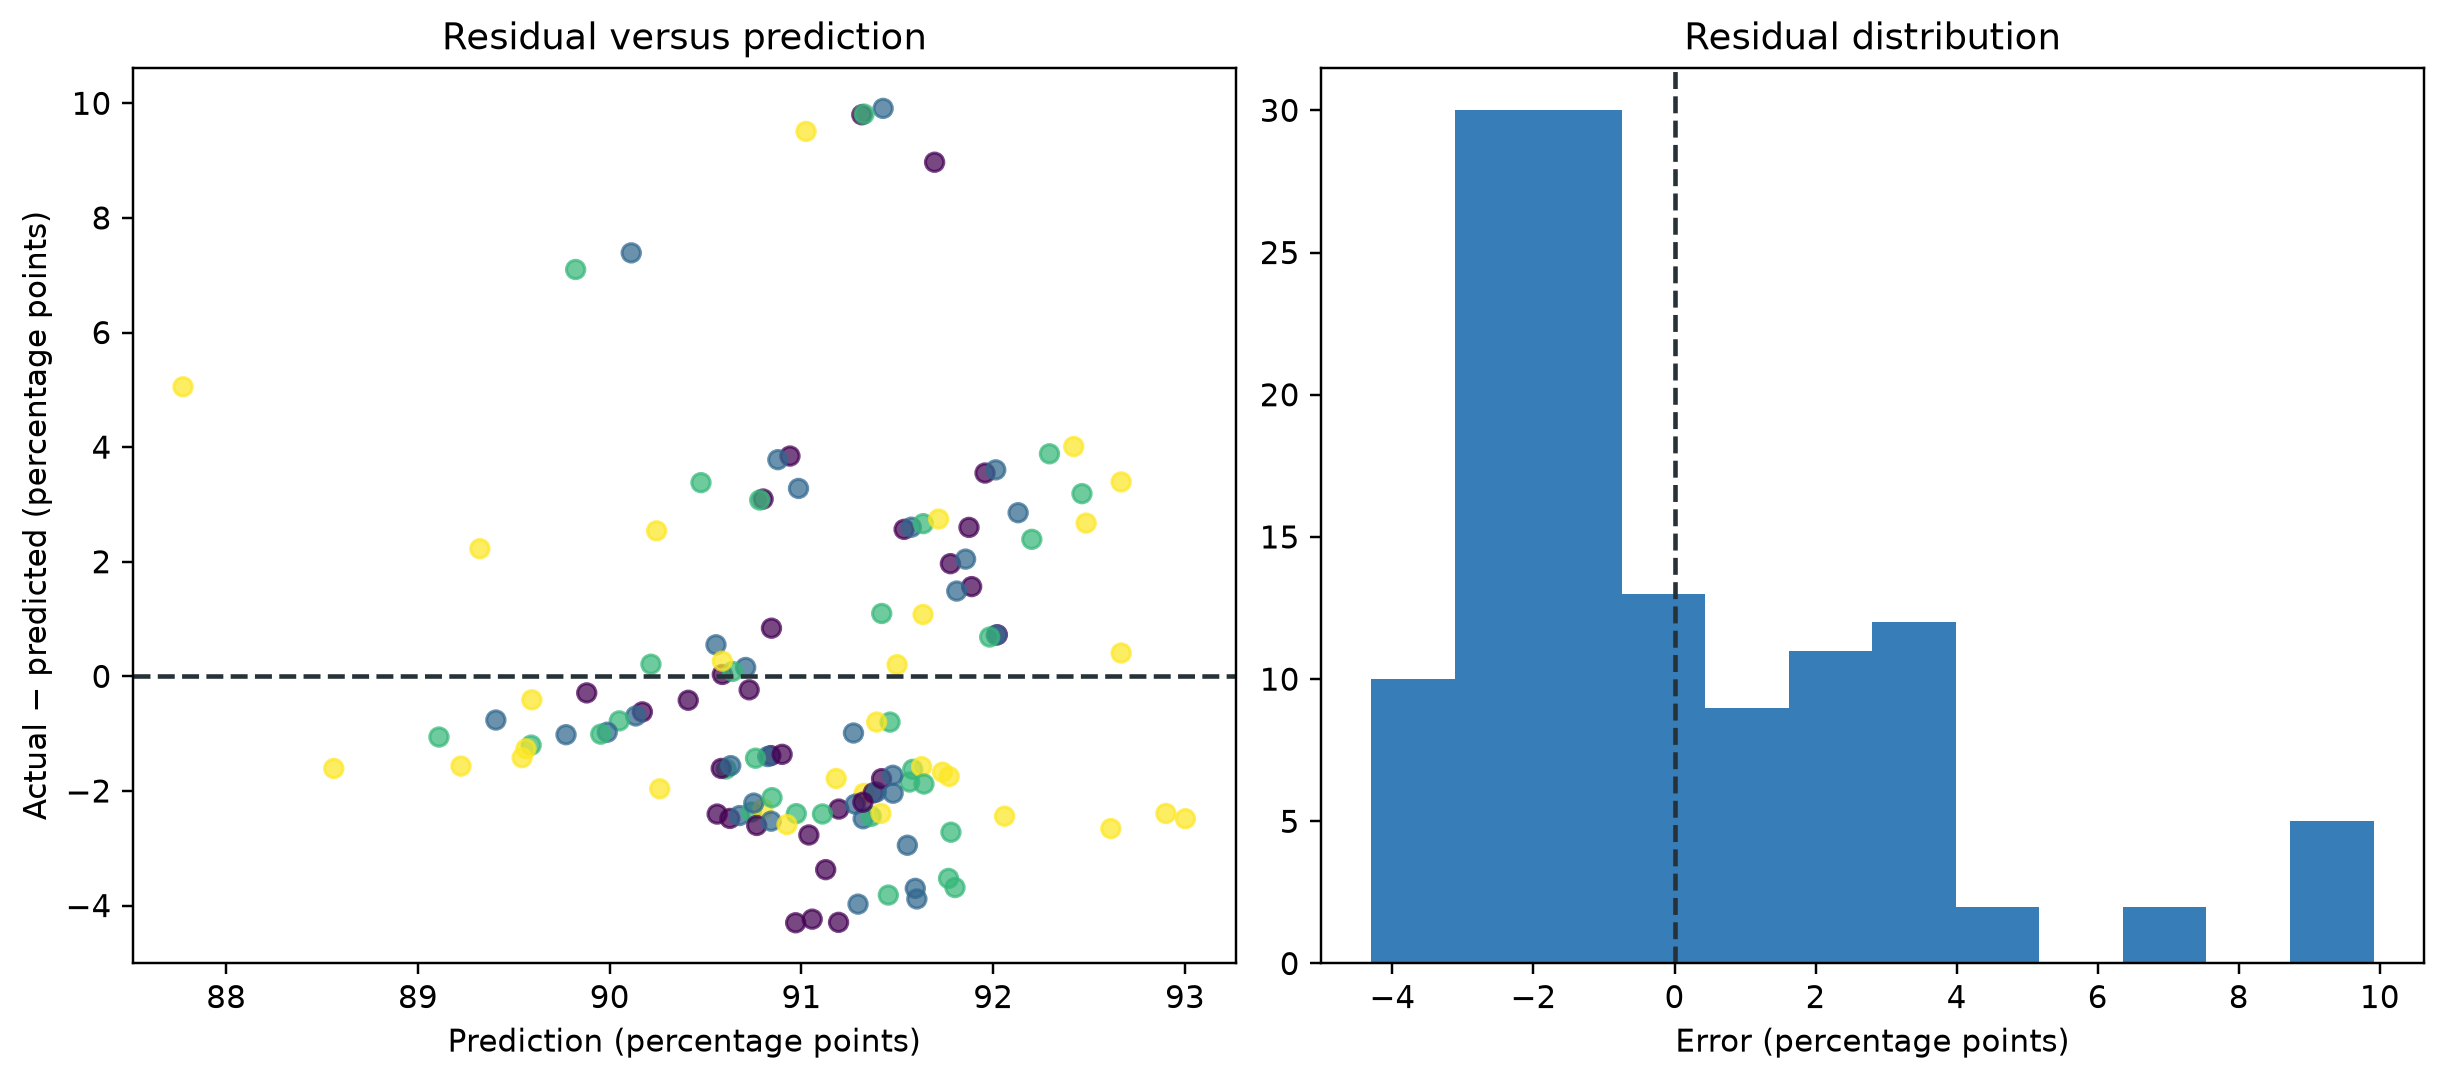

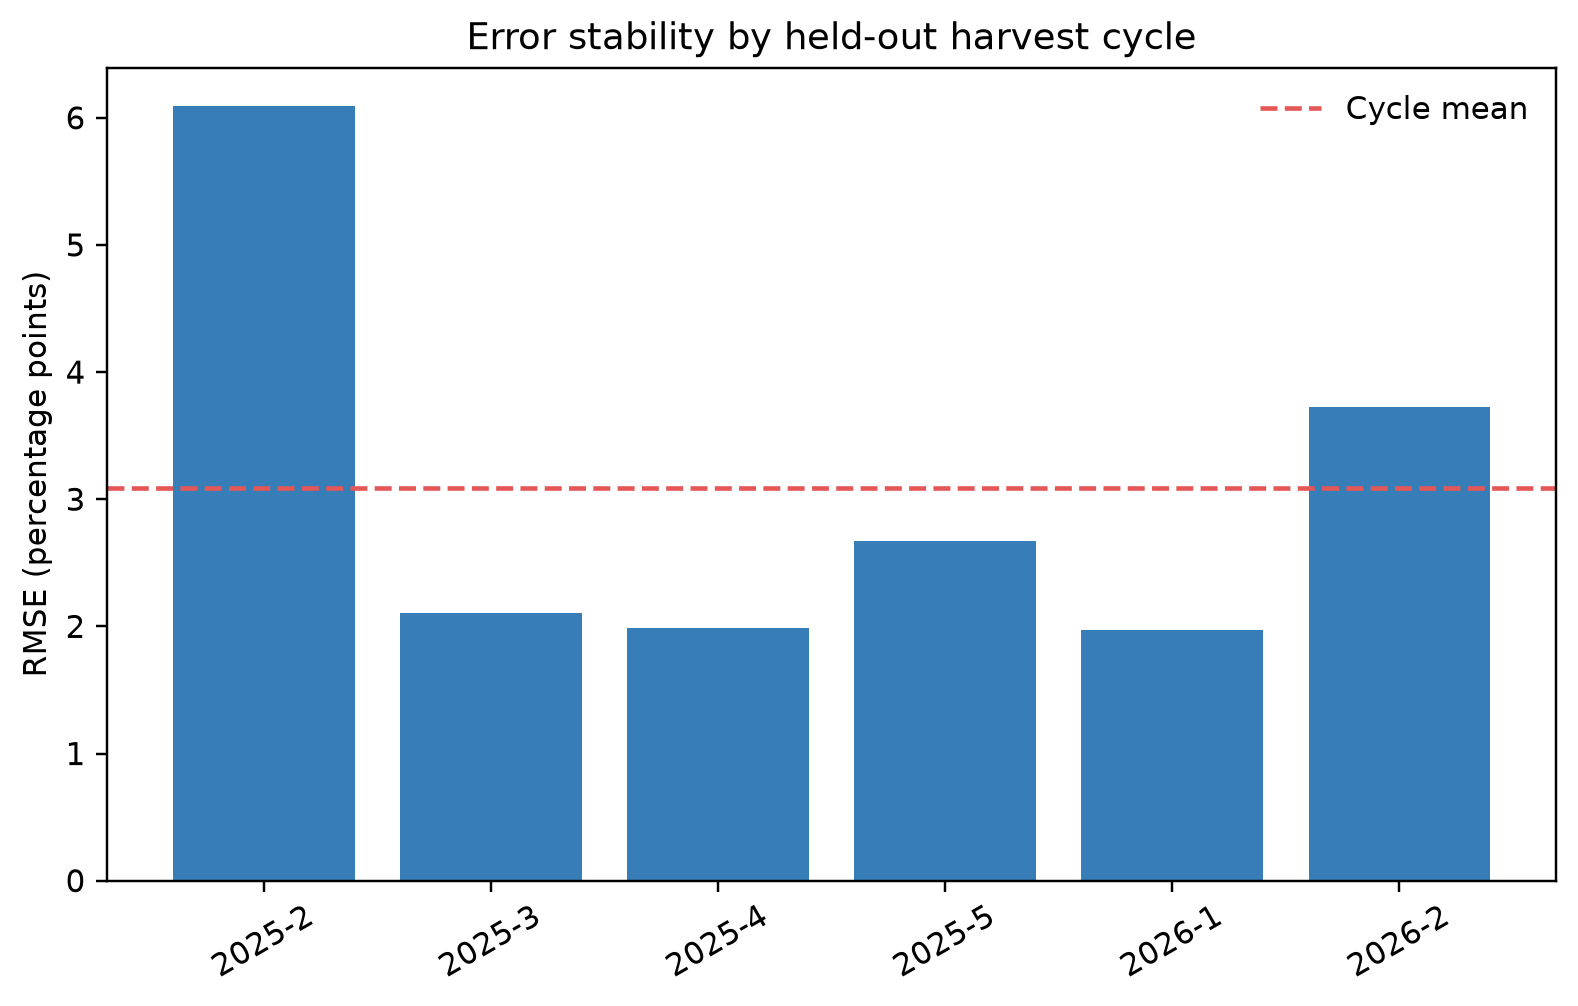

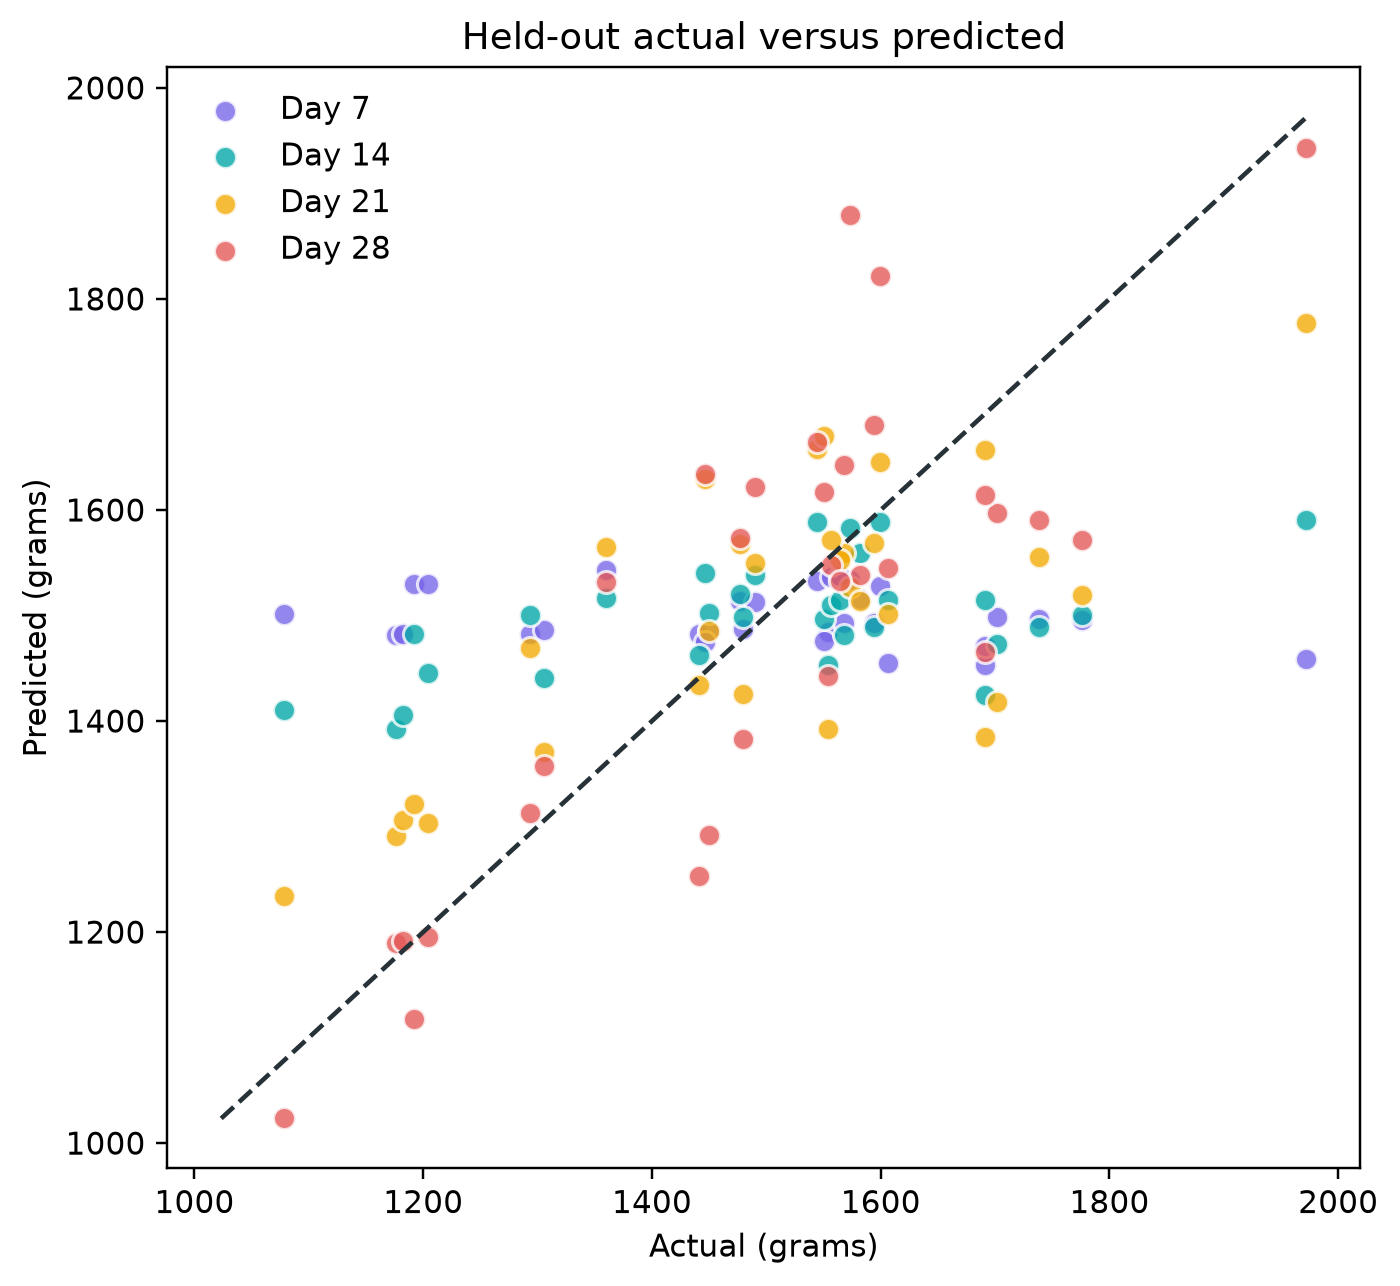

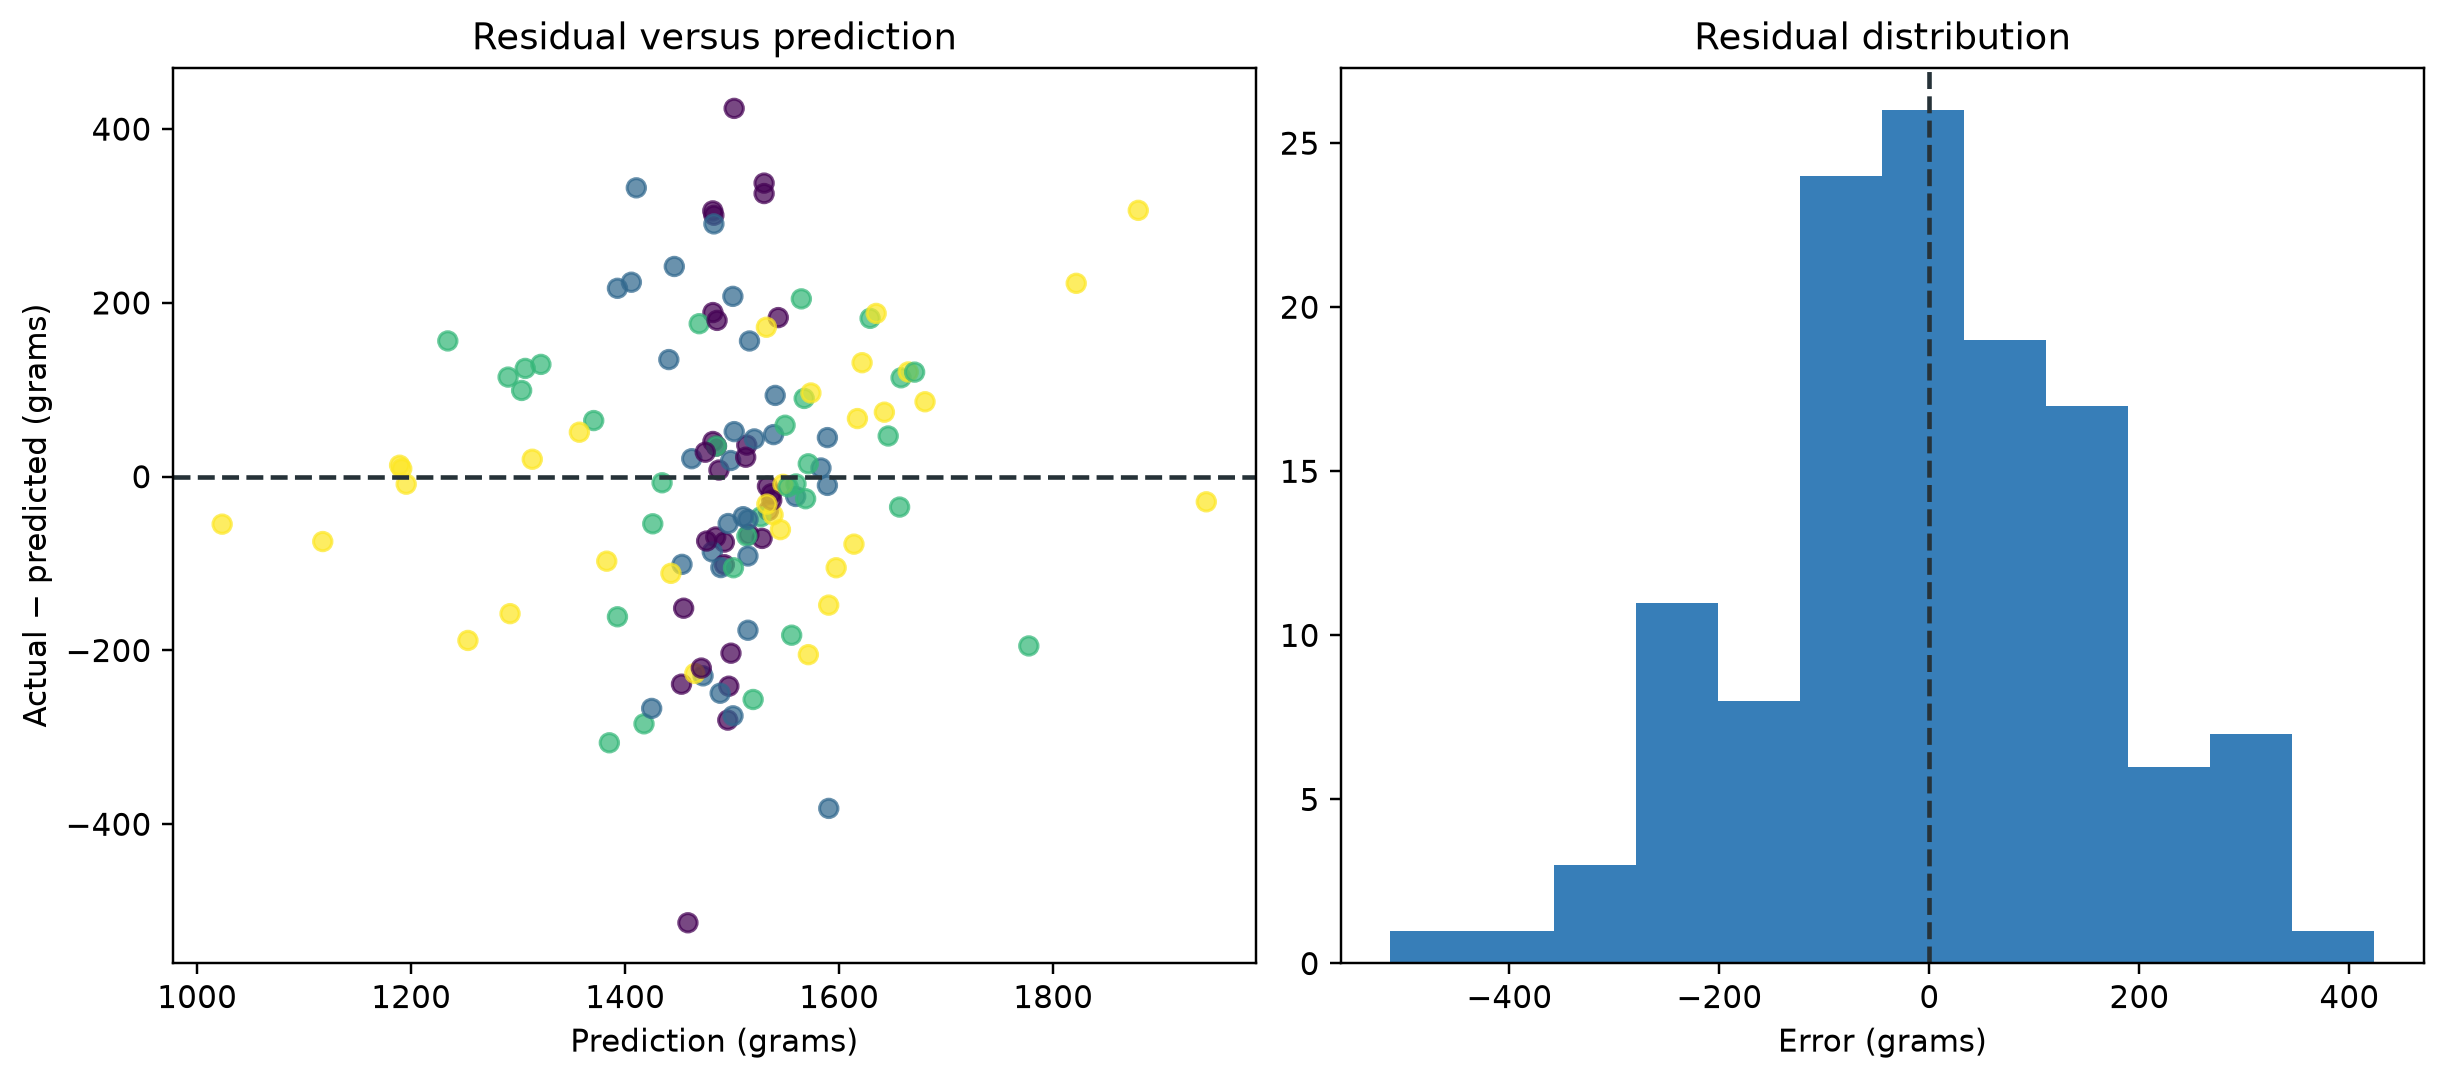

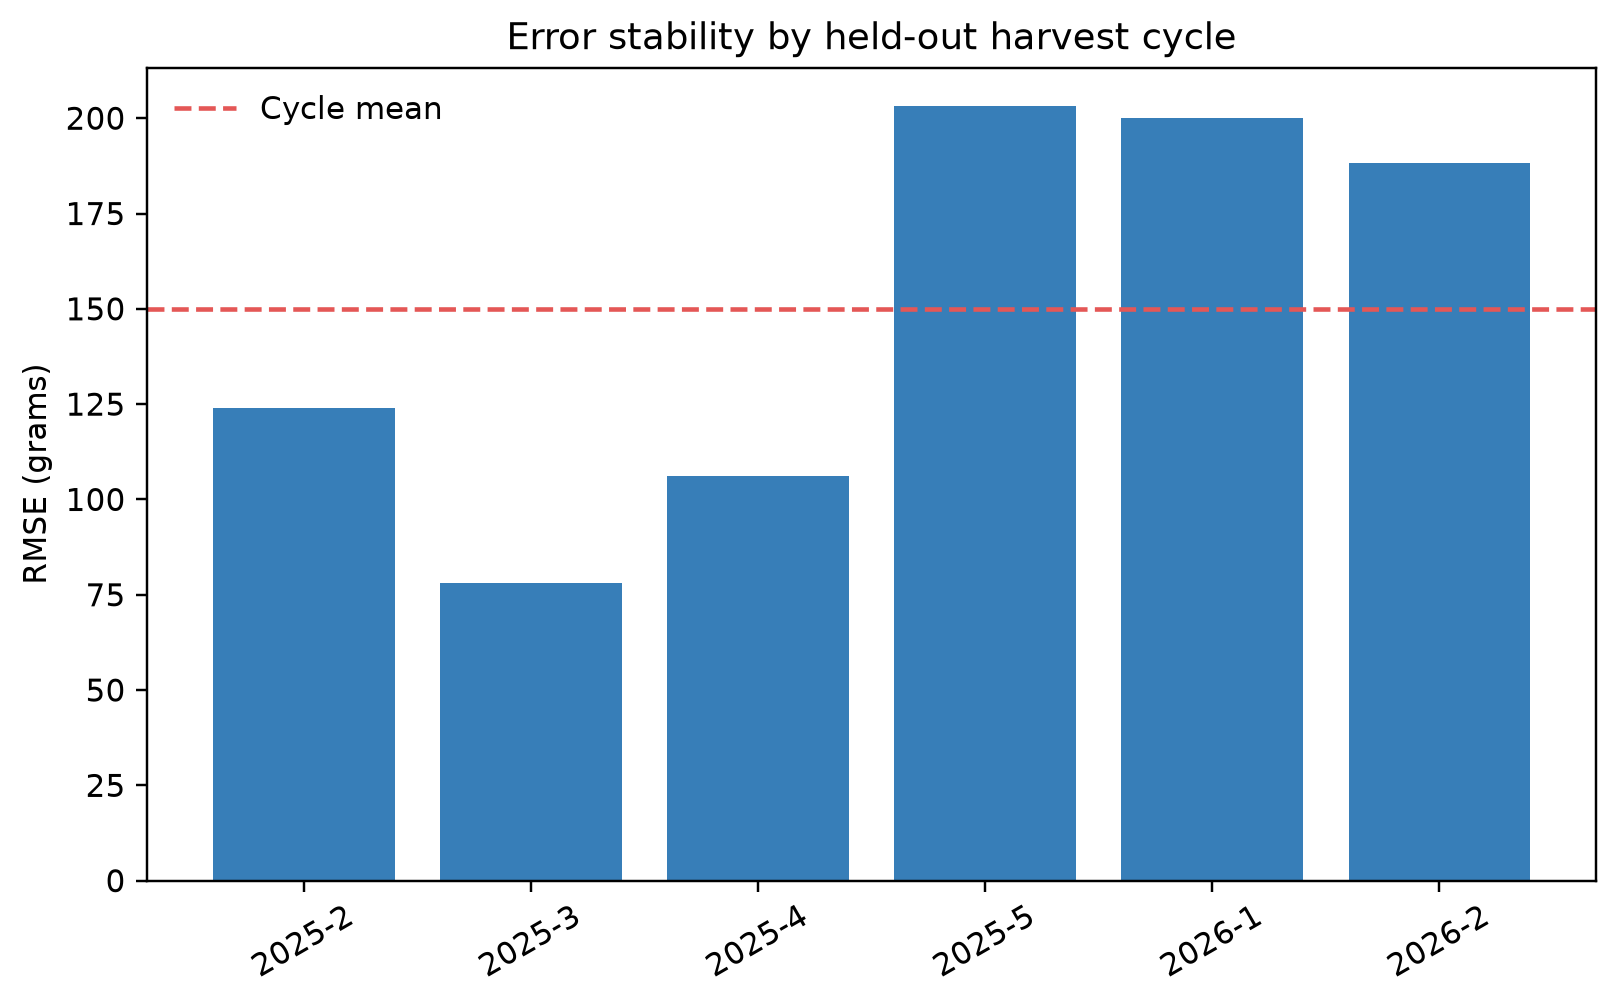

In [9]:
for outcome in ["recovery", "bodyweight"]:
    display(Image(filename=str(OUTPUT_DIR / "capstone_assets" / outcome / "actual_vs_predicted_checkpoints.png"), width=760))
    display(Image(filename=str(OUTPUT_DIR / "capstone_assets" / outcome / "residual_diagnostics.png"), width=950))
    display(Image(filename=str(OUTPUT_DIR / "capstone_assets" / outcome / "fold_stability.png"), width=850))

## 7. Does accuracy improve as more days become available?

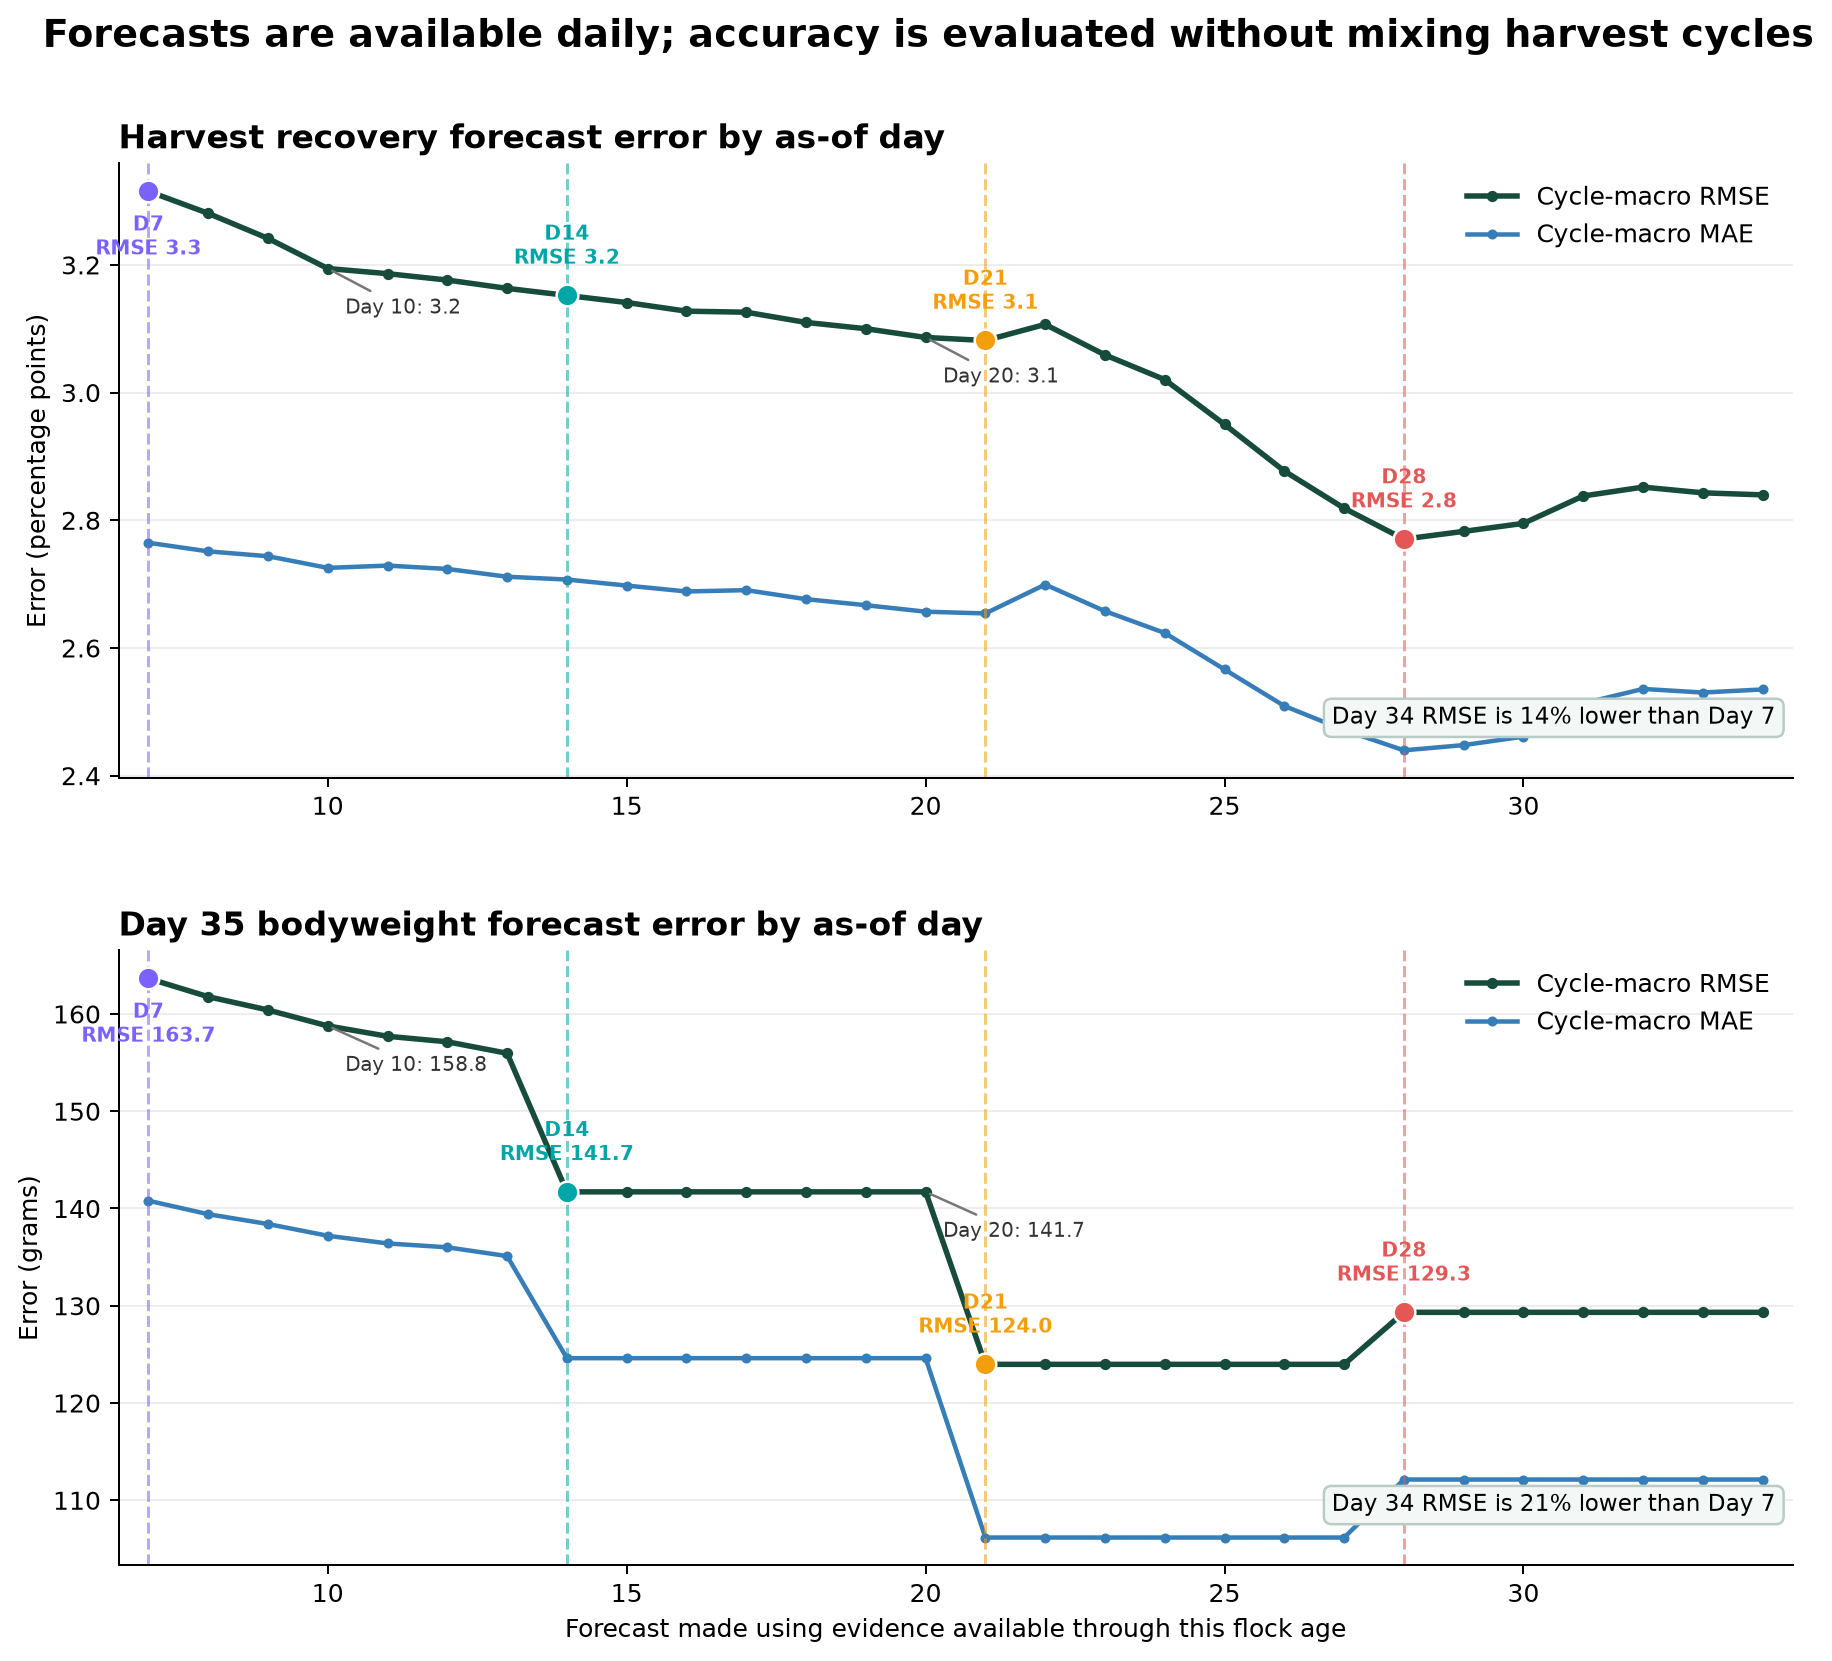

,review_day,n_snapshots,n_building_cycles,n_harvest_cycles,cycle_macro_rmse,cycle_macro_mae,pooled_rmse,pooled_mae,r2,bias,is_validated_checkpoint
0,7,31,31,6,3.315,2.765,3.368,2.589,-0.097,-0.037,True
3,10,31,31,6,3.194,2.725,3.210,2.539,0.004,-0.102,False
7,14,31,31,6,3.152,2.707,3.184,2.515,0.020,-0.039,True
13,20,31,31,6,3.086,2.657,3.123,2.465,0.057,-0.037,False
14,21,31,31,6,3.082,2.654,3.121,2.461,0.058,-0.037,True
21,28,31,31,6,2.771,2.440,2.798,2.233,0.243,-0.033,True
27,34,31,31,6,2.840,2.535,2.768,2.369,0.259,-0.861,False


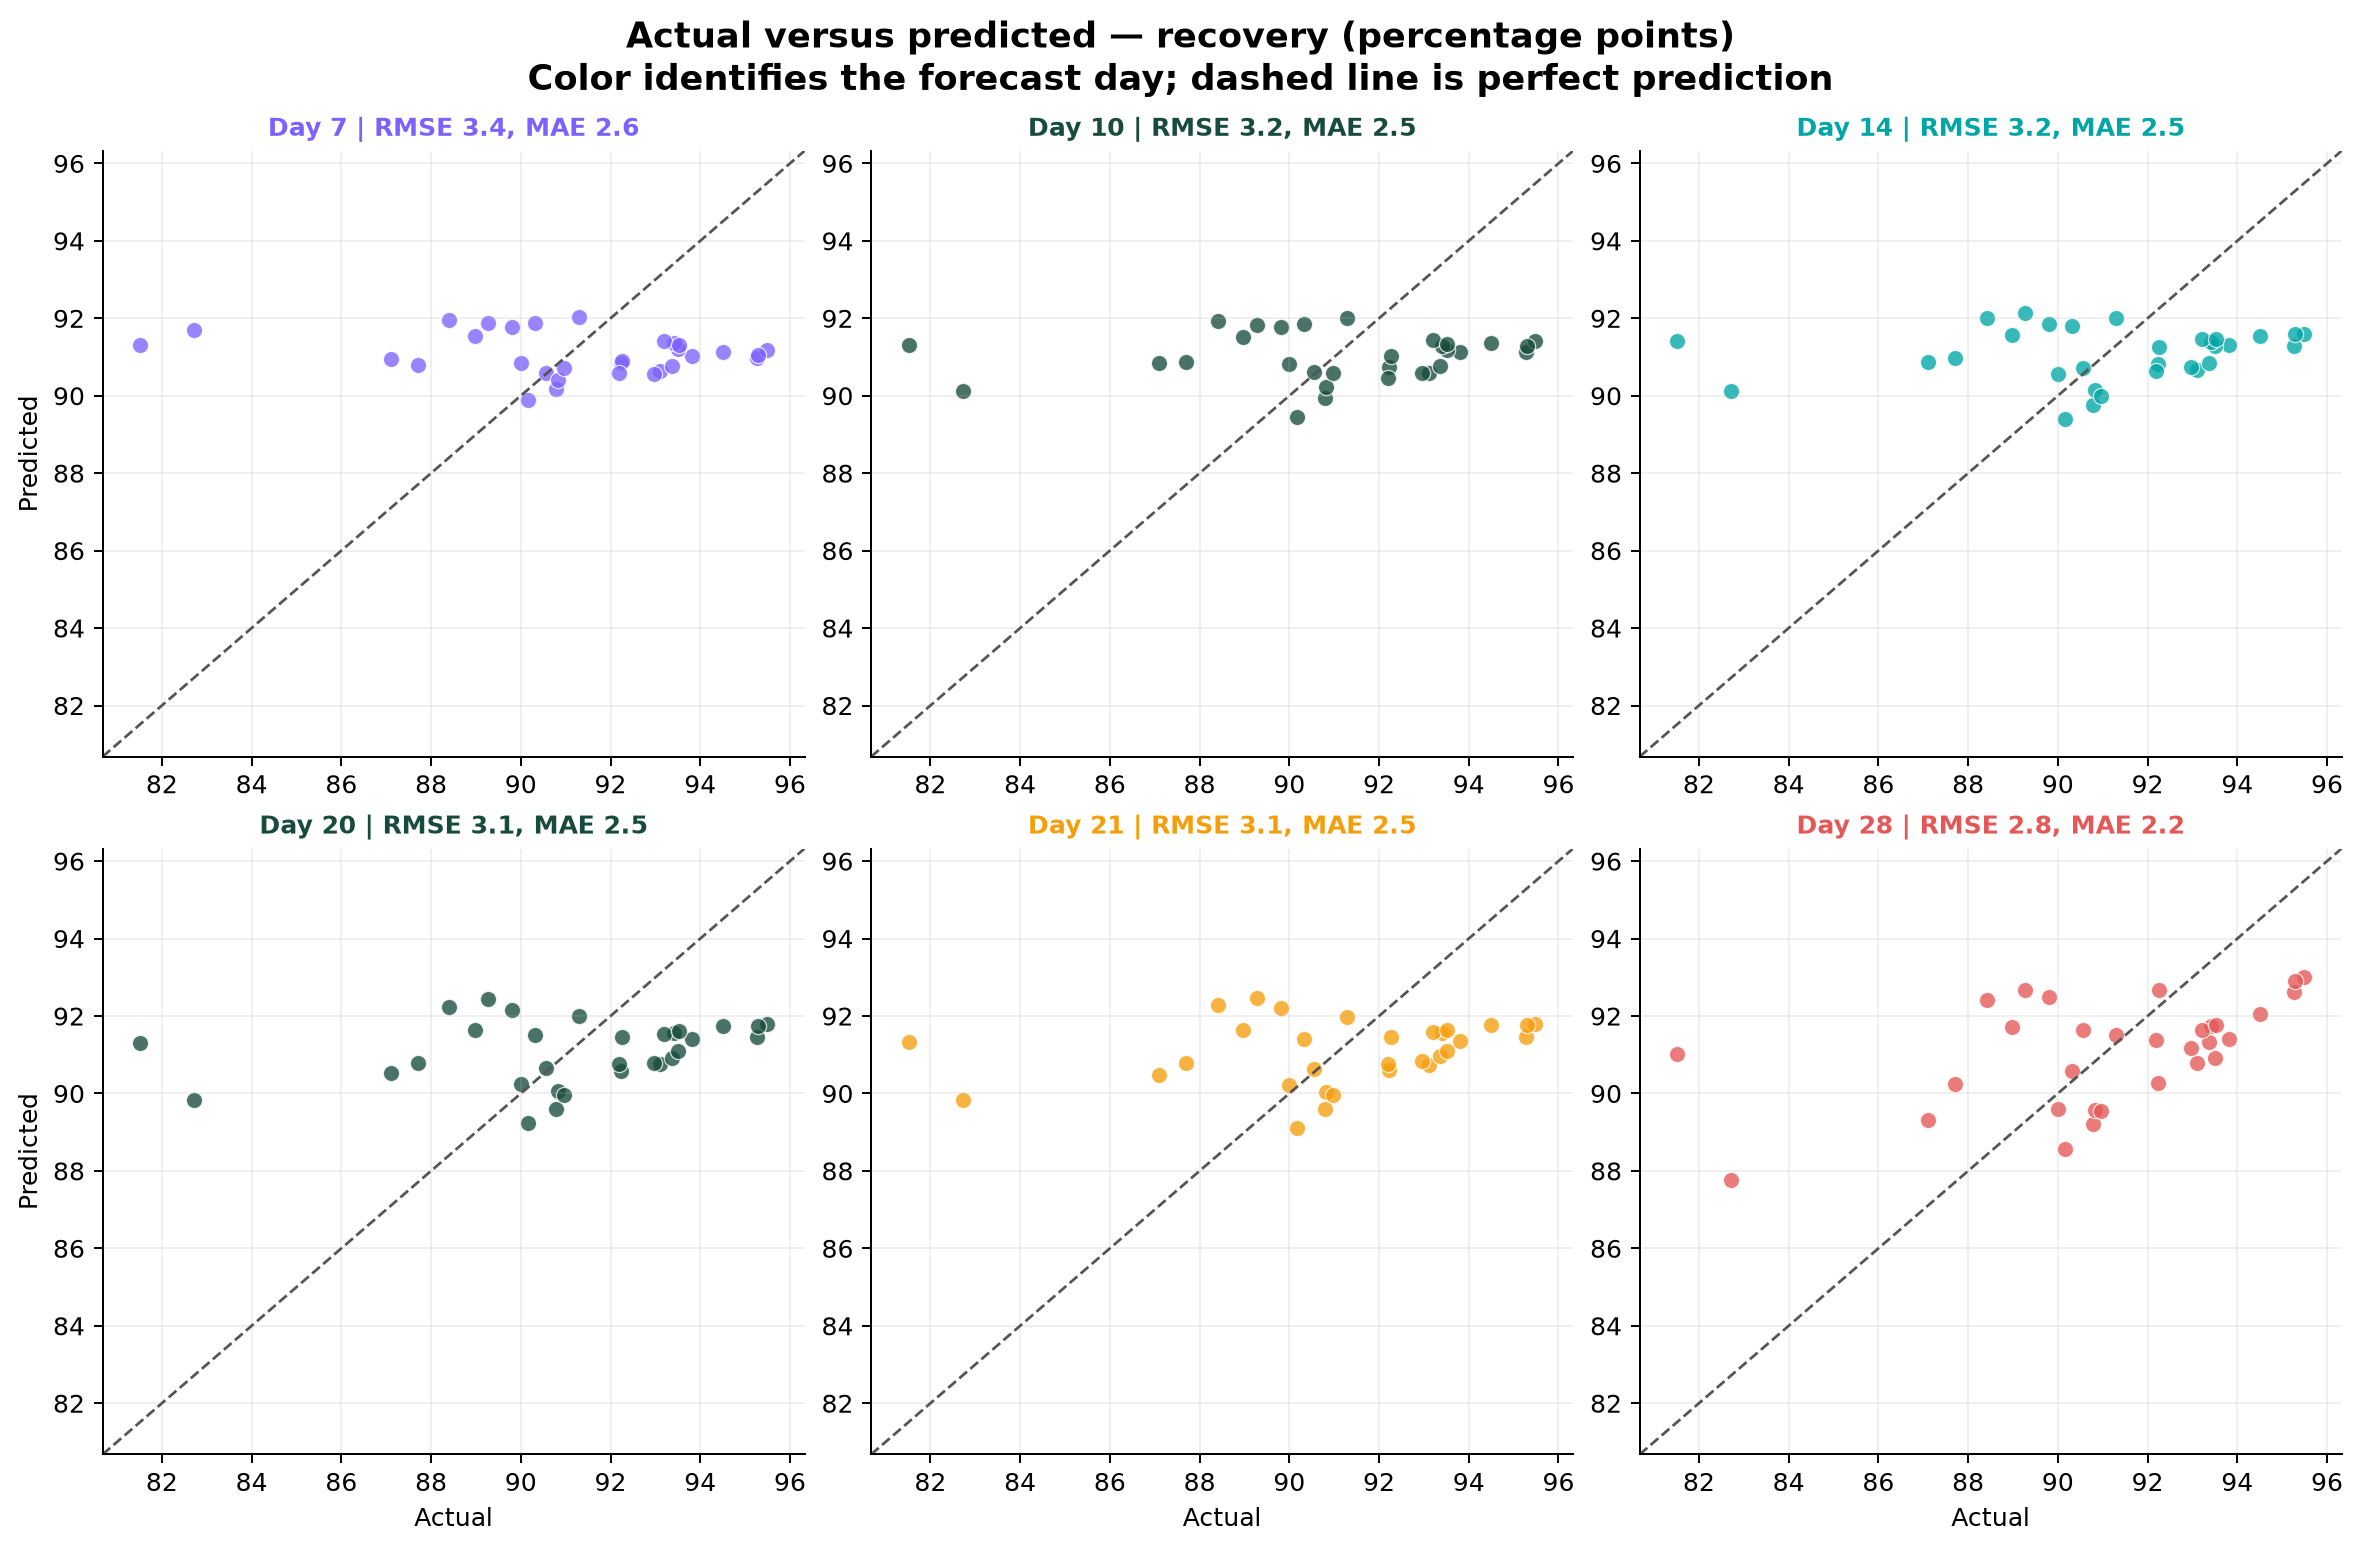

,review_day,n_snapshots,n_building_cycles,n_harvest_cycles,cycle_macro_rmse,cycle_macro_mae,pooled_rmse,pooled_mae,r2,bias,is_validated_checkpoint
0,7,31,31,6,163.653,140.800,204.742,155.450,-0.076,0.445,True
3,10,31,31,6,158.773,137.197,197.573,151.267,-0.002,-3.739,False
7,14,31,31,6,141.711,124.610,173.986,138.061,0.223,-0.272,True
13,20,31,31,6,141.711,124.610,173.986,138.061,0.223,-0.272,False
14,21,31,31,6,123.976,106.168,138.311,112.200,0.509,-0.489,True
21,28,31,31,6,129.324,112.133,127.060,102.772,0.585,-2.269,True
27,34,31,31,6,129.324,112.133,127.060,102.772,0.585,-2.269,False


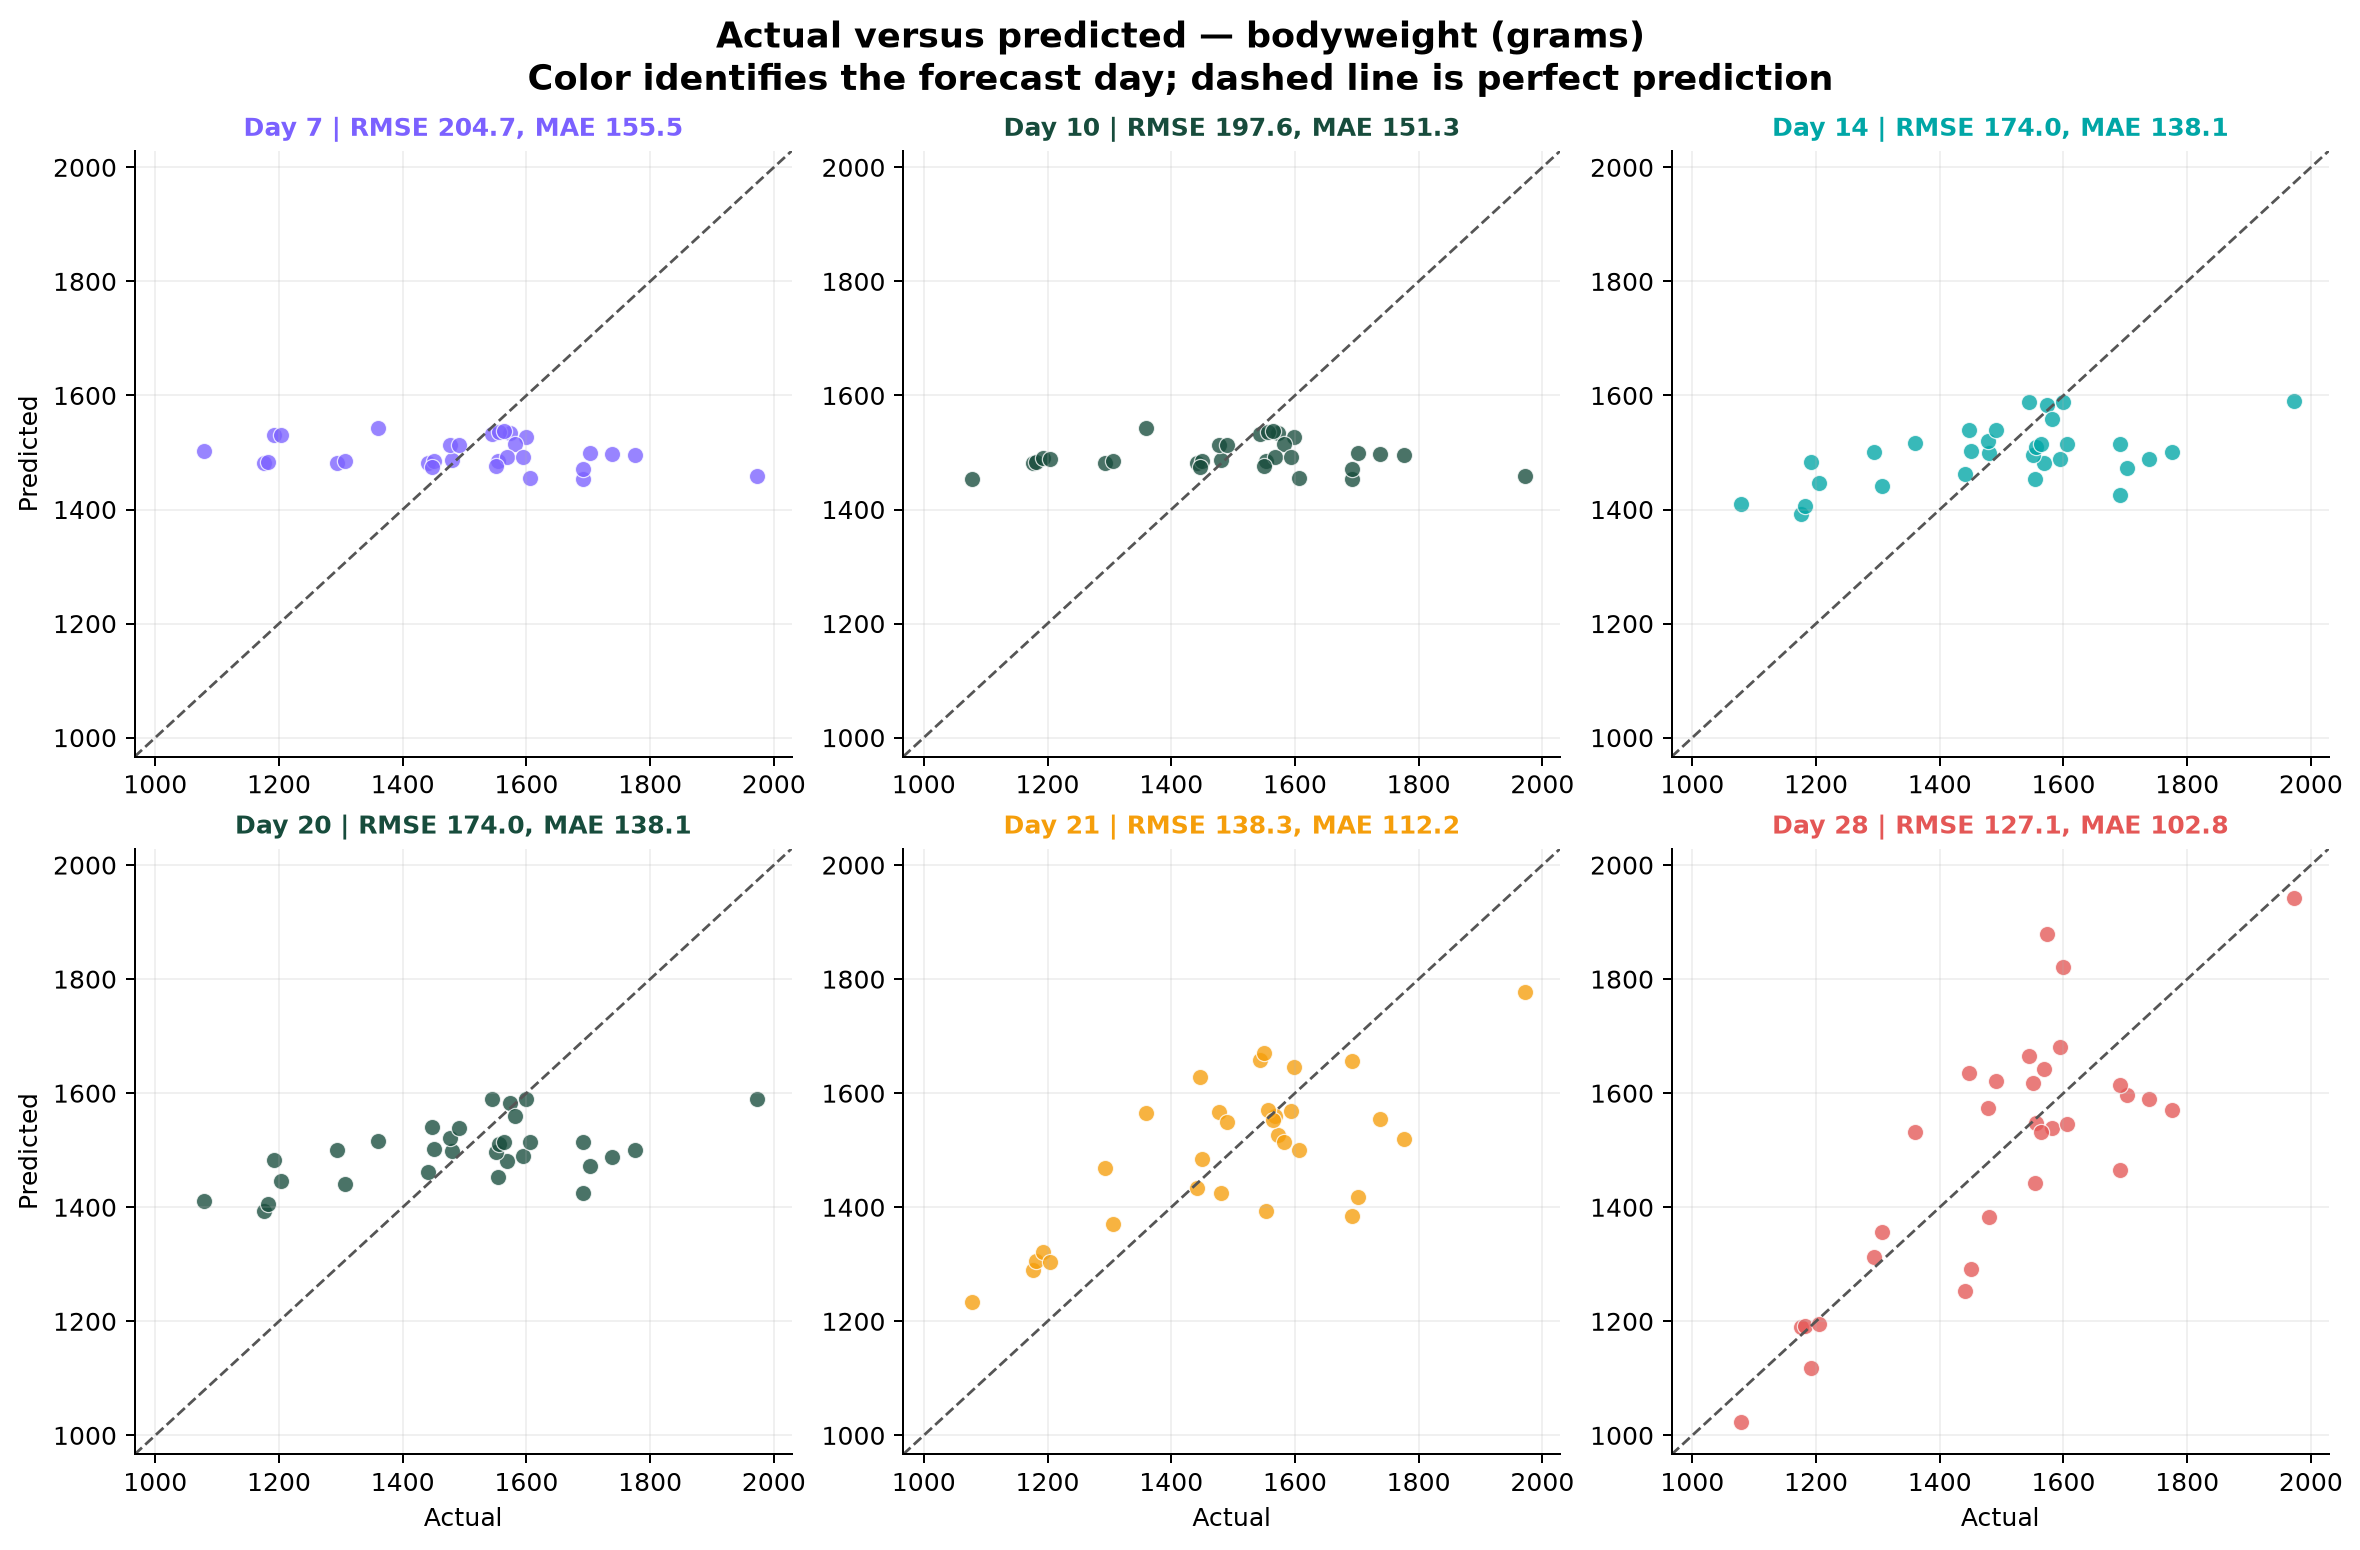

In [10]:
display(Image(filename=str(OUTPUT_DIR / "daily_accuracy" / "daily_forecast_accuracy_learning_curve.png"), width=1000))
for outcome in ["recovery", "bodyweight"]:
    daily = pd.read_csv(OUTPUT_DIR / "daily_accuracy" / f"{outcome}_daily_metrics.csv")
    display(daily.loc[daily.review_day.isin([7, 10, 14, 20, 21, 28, 34])].round(3))
    display(Image(filename=str(OUTPUT_DIR / "daily_accuracy" / f"{outcome}_actual_vs_predicted_by_day.png"), width=1000))

**Interpretation:** forecasts are available on Day 10, Day 20 and every day from Day 7–34. Days 7/14/21/28 are validation anchors. Recovery updates with new population and mortality evidence. Bodyweight forecasts improve mainly when a genuinely new weight measurement is recorded; a stale measurement is never relabelled as a new daily measurement.

## 8. Uncertainty and target-side performance

RECOVERY interval coverage


,covered_80,covered_90
review_day,,
7,0.774,0.839
14,0.806,0.935
21,0.742,0.935
28,0.677,0.871


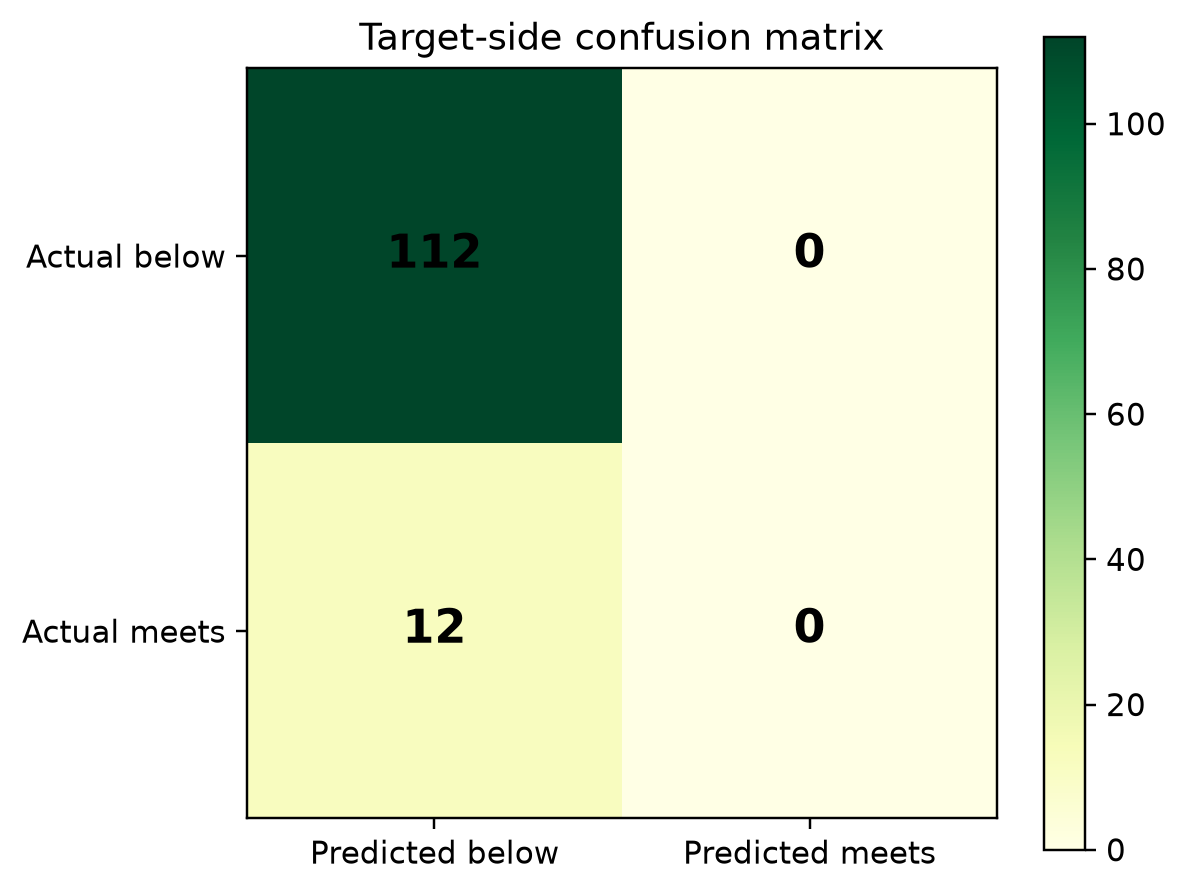

BODYWEIGHT interval coverage


,covered_80,covered_90
review_day,,
7,0.645,0.806
14,0.677,0.903
21,0.871,0.935
28,0.710,0.839


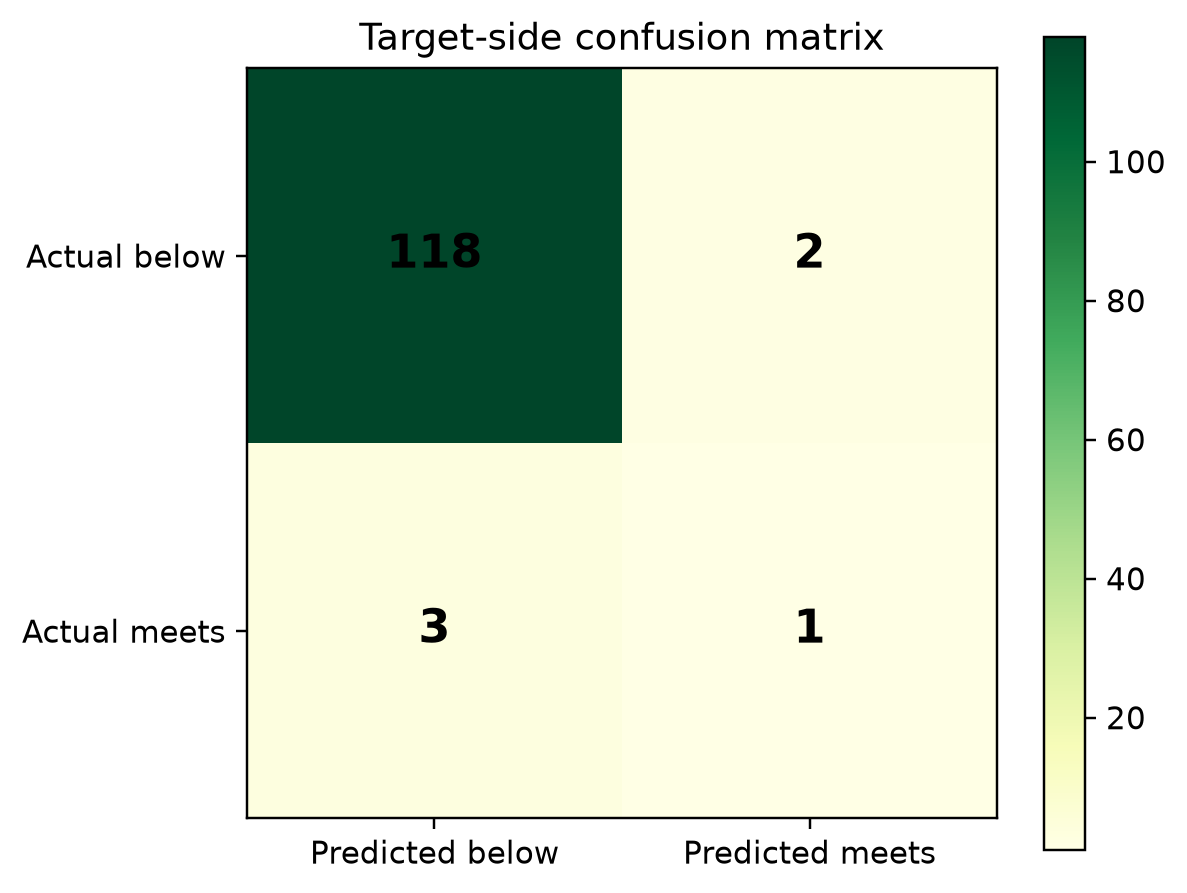

In [11]:
for outcome in ["recovery", "bodyweight"]:
    intervals = pd.read_csv(OUTPUT_DIR / outcome / "conformal_predictions.csv")
    coverage = intervals.groupby("review_day")[["covered_80", "covered_90"]].mean()
    print(outcome.upper(), "interval coverage")
    display(coverage.round(3))
    display(Image(filename=str(OUTPUT_DIR / "capstone_assets" / outcome / "target_confusion_matrix.png"), width=620))

## 9. Feature importance and SHAP


 RECOVERY


,candidate,feature,mean_abs_shap,mean_shap,value_shap_correlation,positive_fold_direction_rate,direction_stable
0,residual_lightgbm_peer,beginning_inventory,0.0,0.0,NaN,0.0,True
55,residual_lightgbm_peer,missingindicator_environment_staleness_days,0.0,0.0,NaN,0.0,True
53,residual_lightgbm_peer,environment_coverage_x_horizon,0.0,0.0,NaN,0.0,True
52,residual_lightgbm_peer,environment_missing_both,0.0,0.0,NaN,0.0,True
51,residual_lightgbm_peer,environment_recorded_days,0.0,0.0,NaN,0.0,True
50,residual_lightgbm_peer,environment_staleness_days,0.0,0.0,NaN,0.0,True
49,residual_lightgbm_peer,humidity_high_excess_days,0.0,0.0,NaN,0.0,True
48,residual_lightgbm_peer,humidity_history_avg_pct,0.0,0.0,NaN,0.0,True
47,residual_lightgbm_peer,humidity_history_sd_pct,0.0,0.0,NaN,0.0,True
46,residual_lightgbm_peer,humidity_low_excess_days,0.0,0.0,NaN,0.0,True


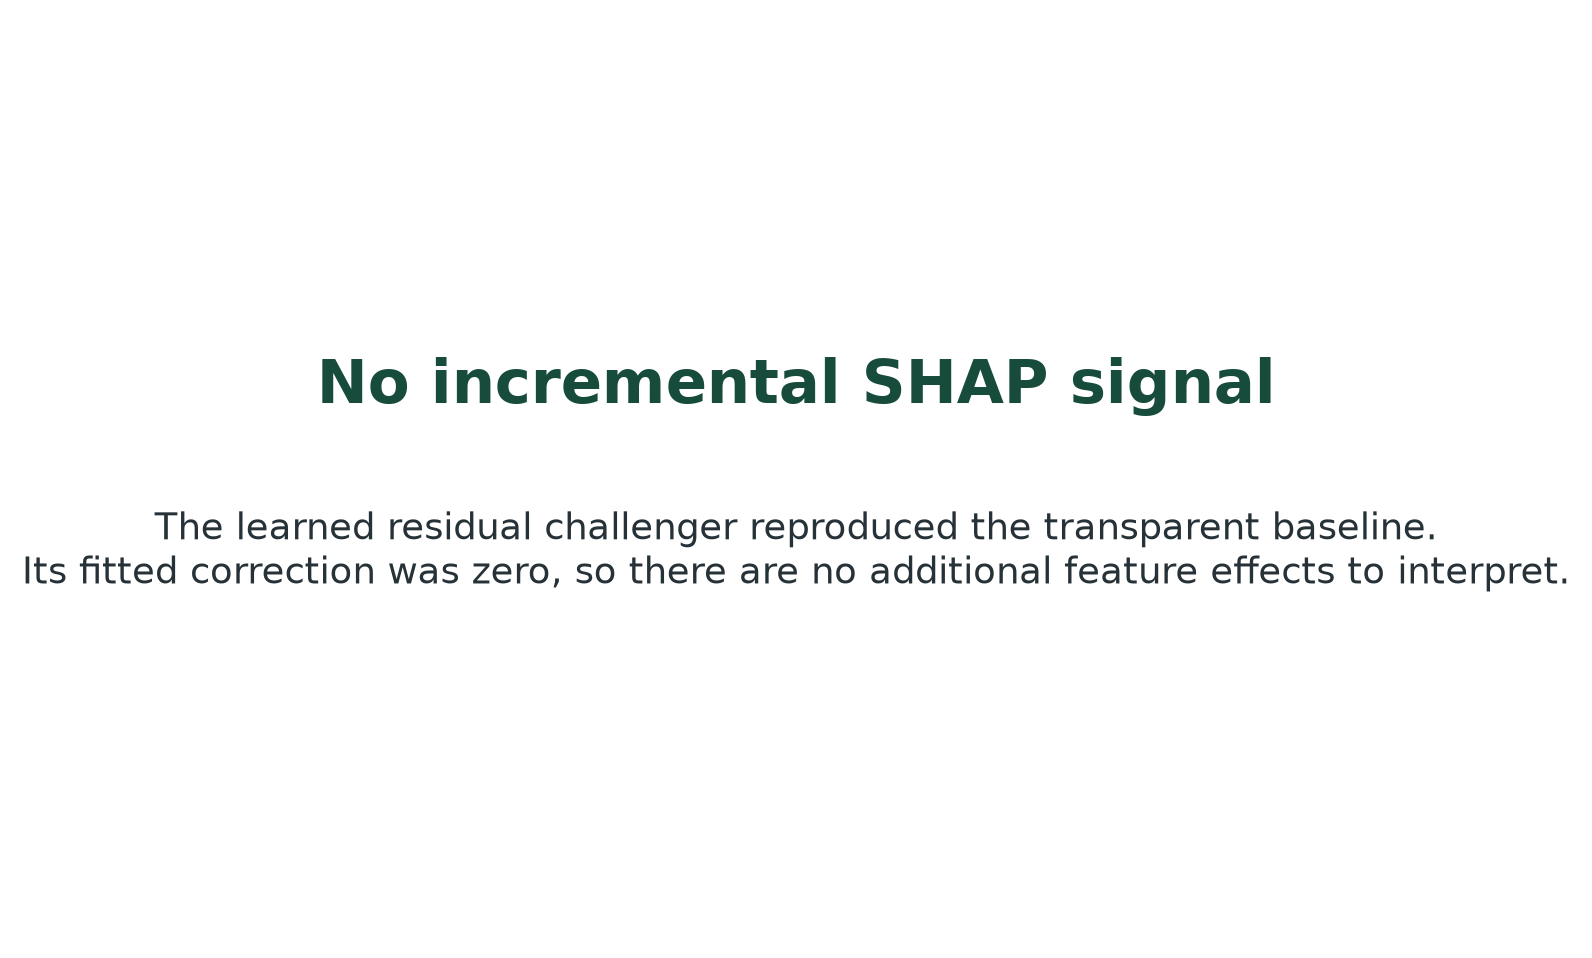

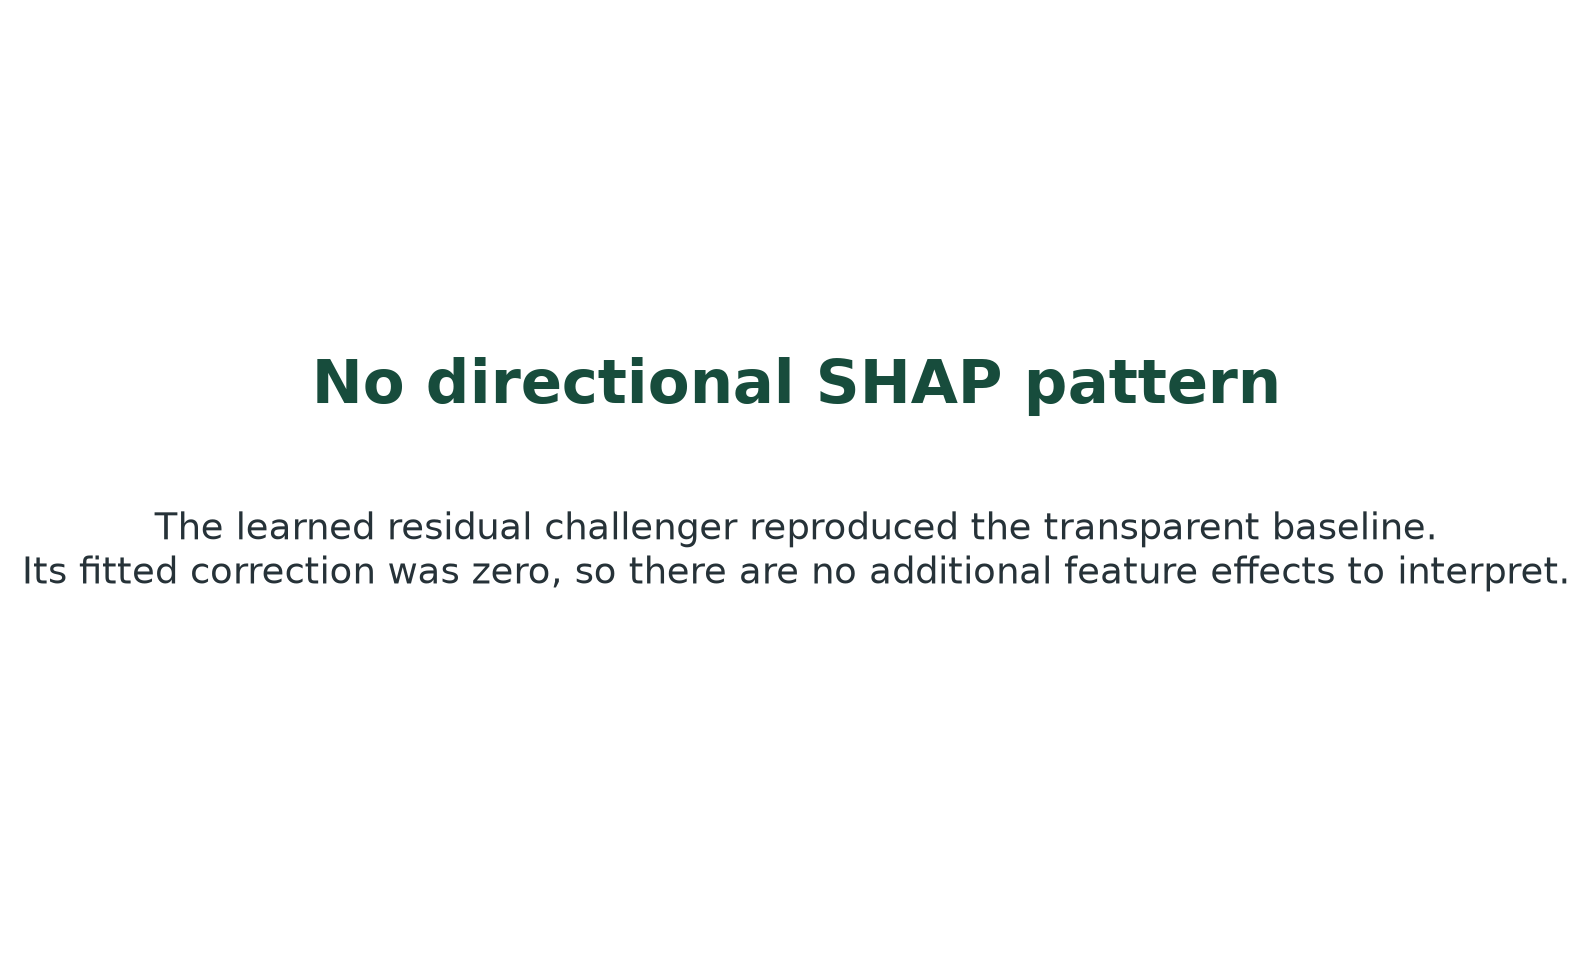

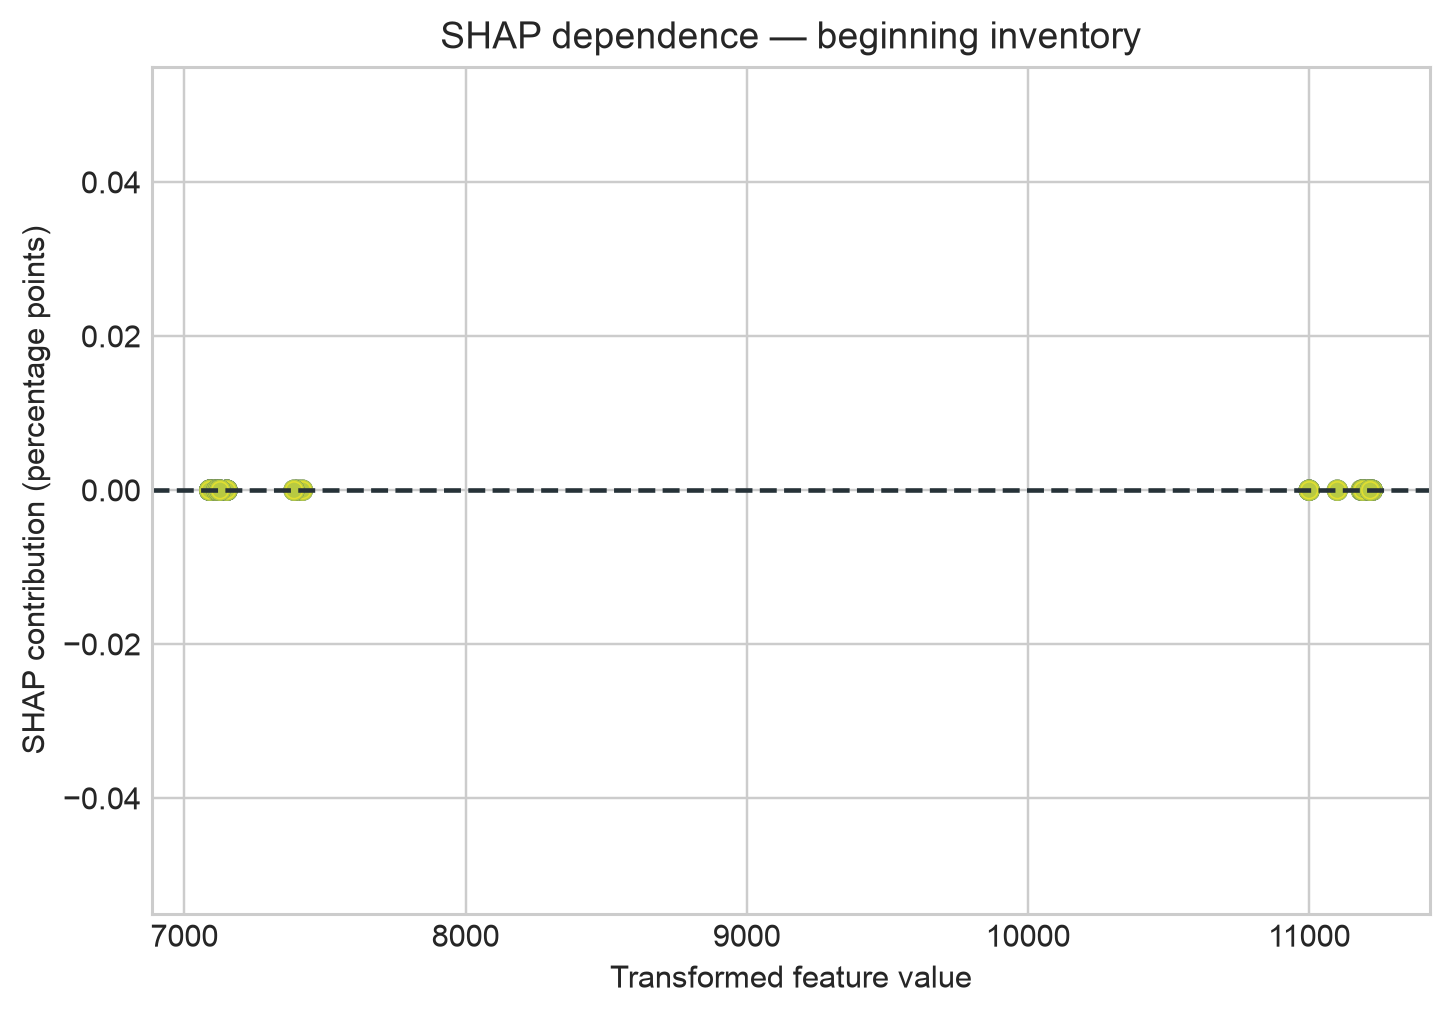

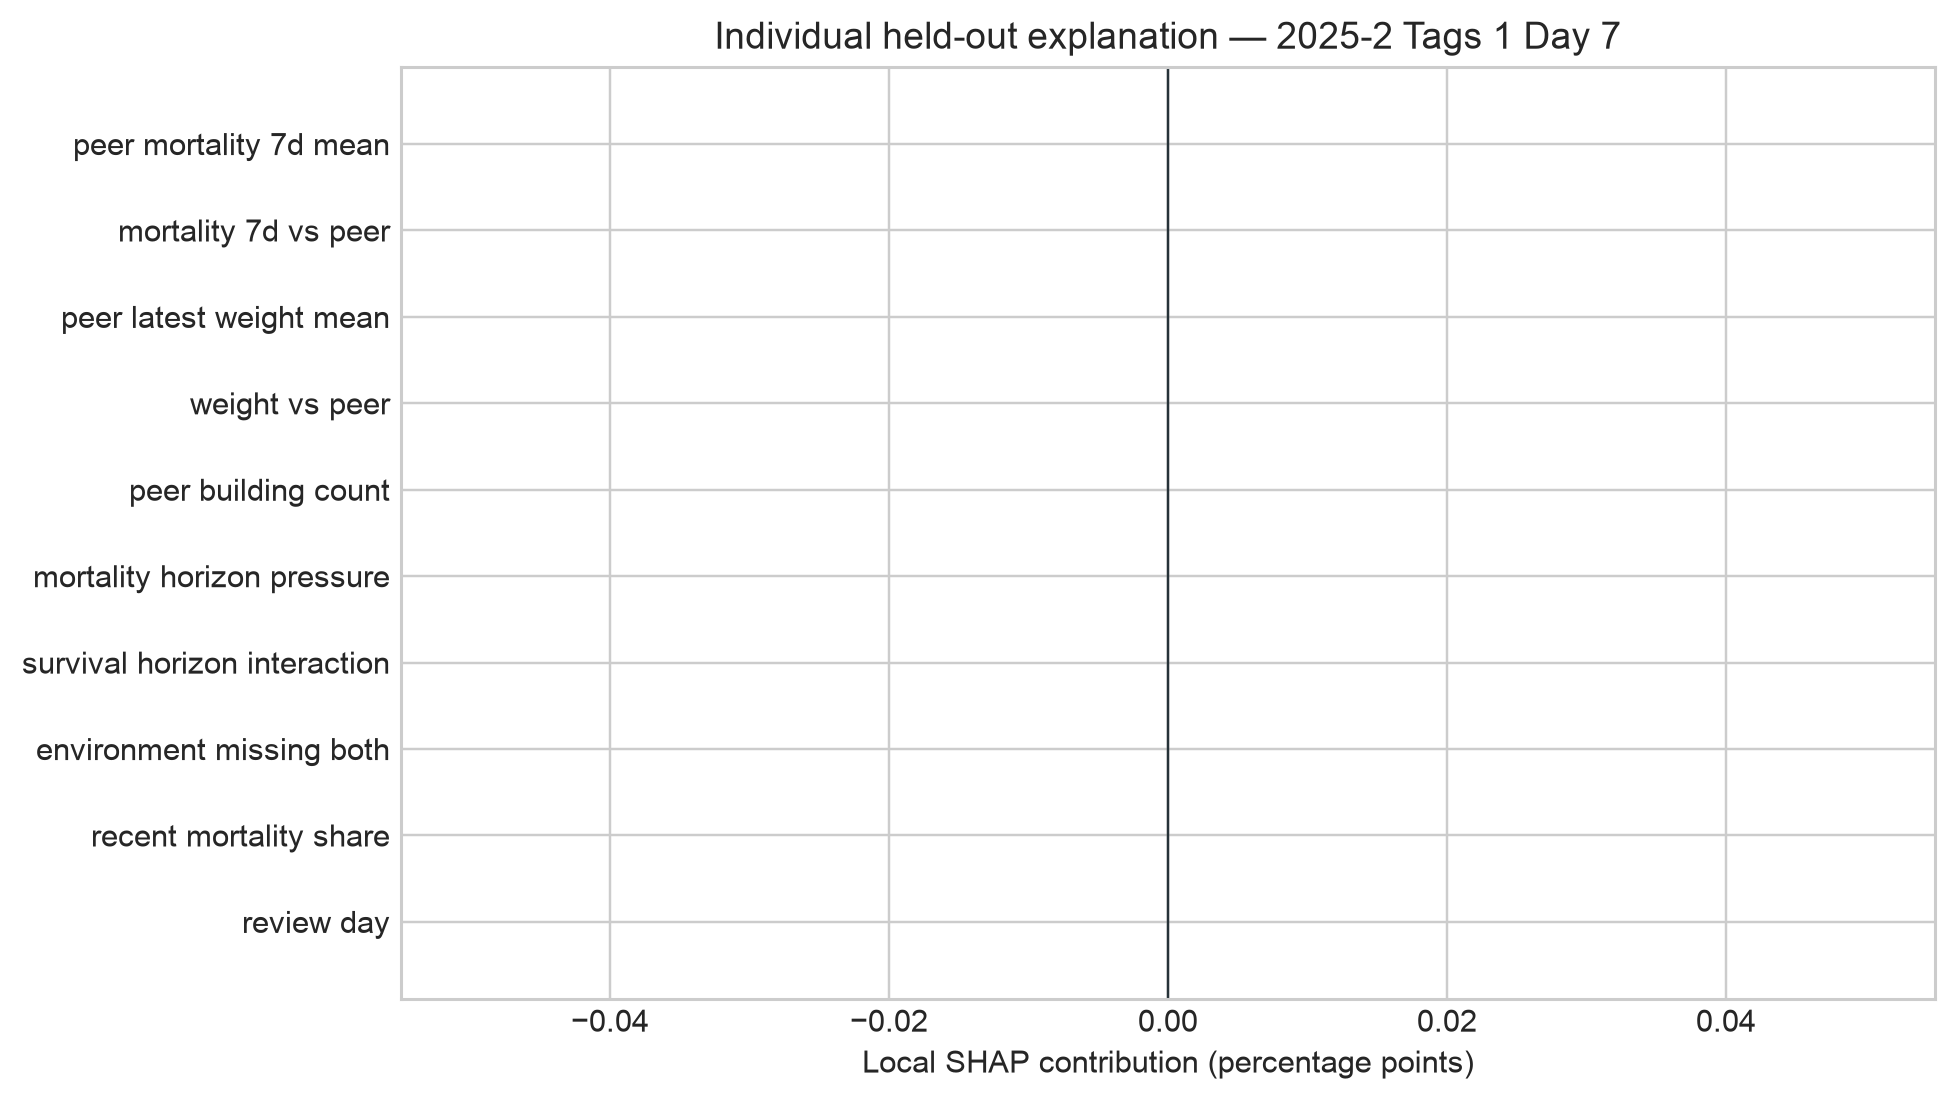


 BODYWEIGHT


,candidate,feature,mean_abs_shap,mean_shap,value_shap_correlation,positive_fold_direction_rate,direction_stable
0,residual_xgboost_peer,peer_survival_mean_pct,7.5566,-3.0992,0.2236,0.1667,True
1,residual_xgboost_peer,peer_current_weight_mean_g,7.3888,-5.6844,0.5750,0.3333,False
2,residual_xgboost_peer,weight_day21_g,6.8856,0.6625,-0.7420,0.5000,False
3,residual_xgboost_peer,weight_day7_g,6.0411,3.2137,0.0529,0.8333,True
4,residual_xgboost_peer,current_weight_g,5.4585,1.0361,0.0415,0.8333,True
5,residual_xgboost_peer,mortality_x_days_remaining,4.7579,-2.2474,-0.6534,0.5000,False
6,residual_xgboost_peer,current_weight_vs_peer_g,3.9893,-0.2610,-0.1386,0.6667,False
7,residual_xgboost_peer,log_beginning_inventory,2.9392,0.3386,-0.4611,0.8333,True
8,residual_xgboost_peer,survival_pct,2.8243,-2.4499,-0.3845,0.2500,False
9,residual_xgboost_peer,temperature_coverage,1.6445,0.2790,-0.1218,0.6000,False


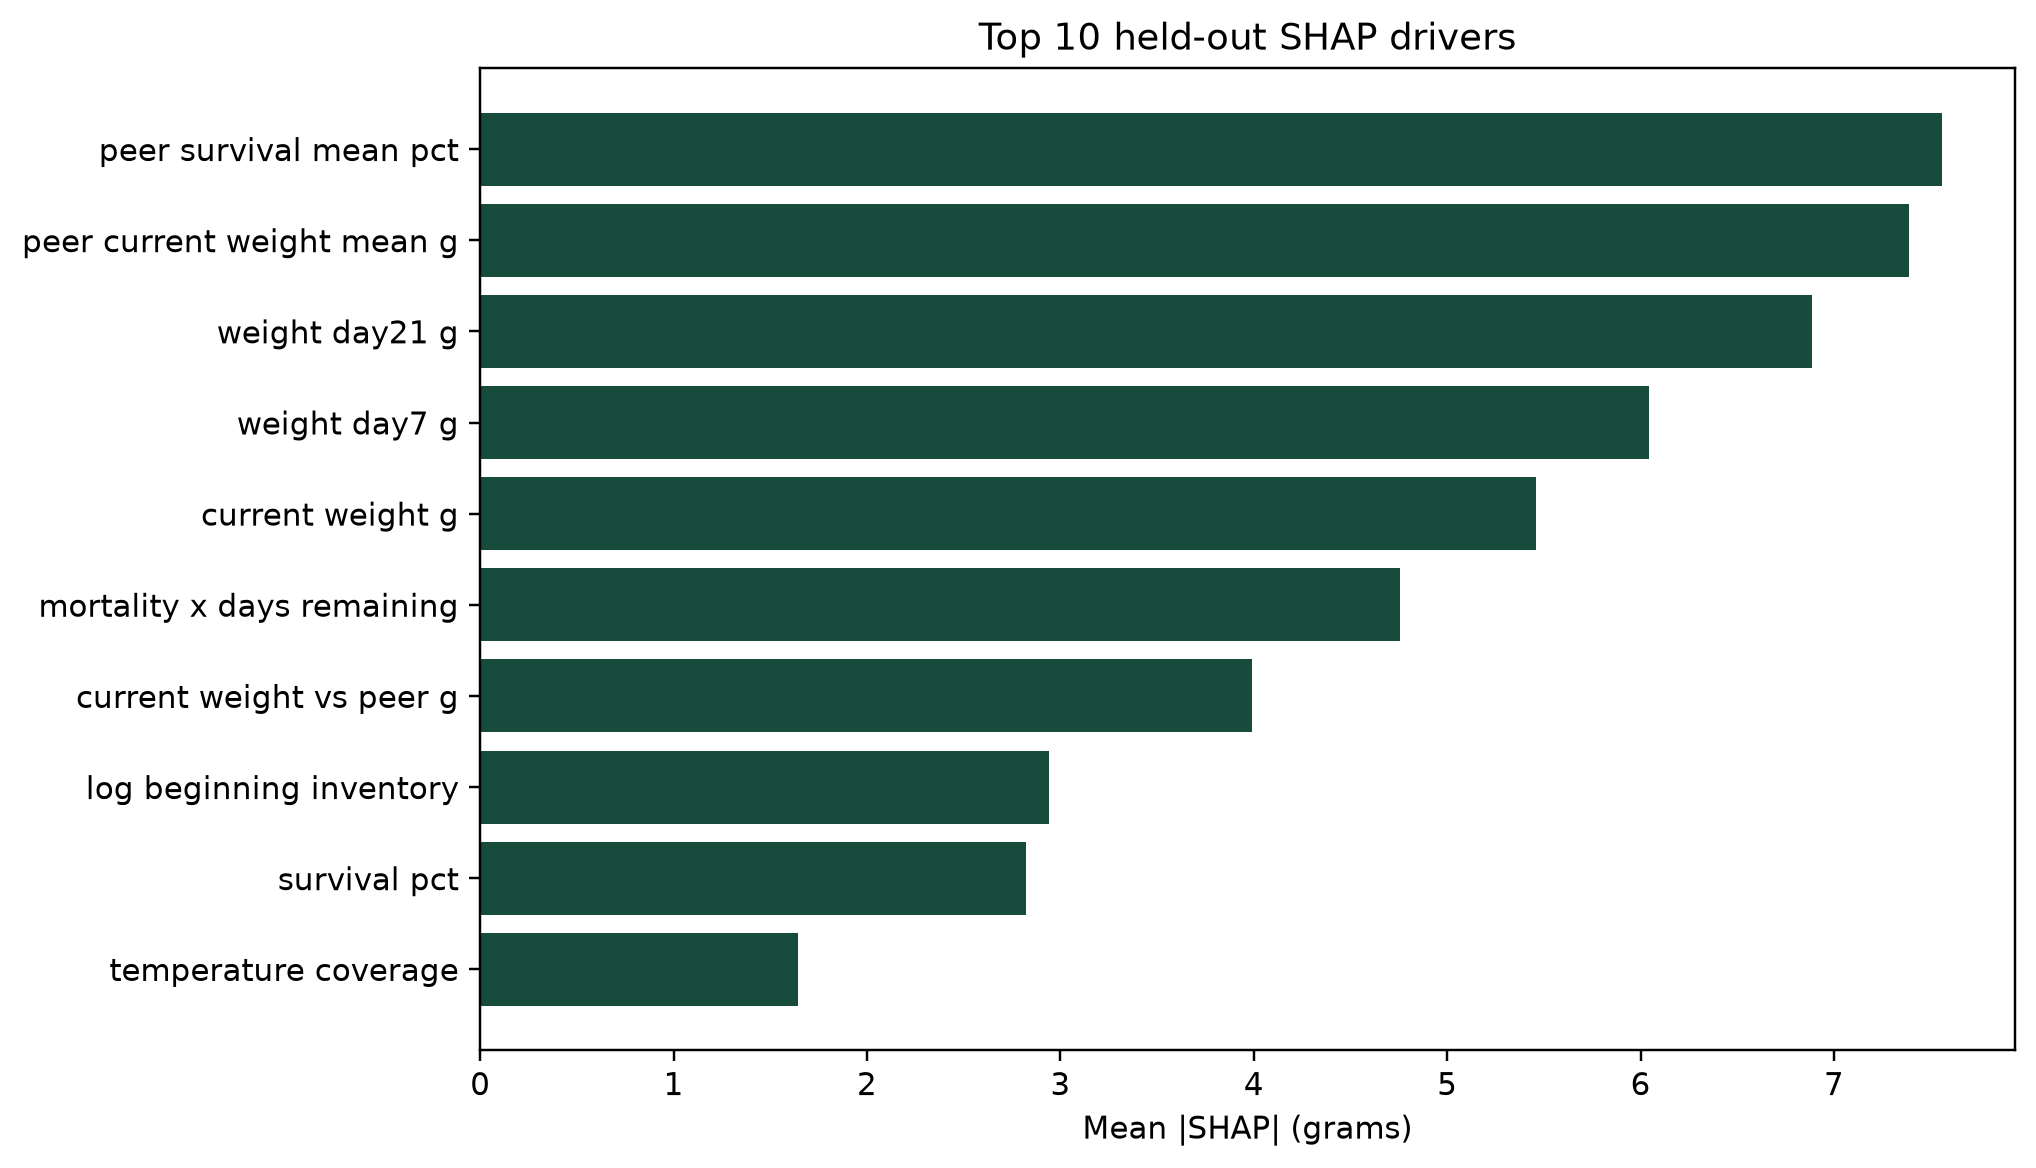

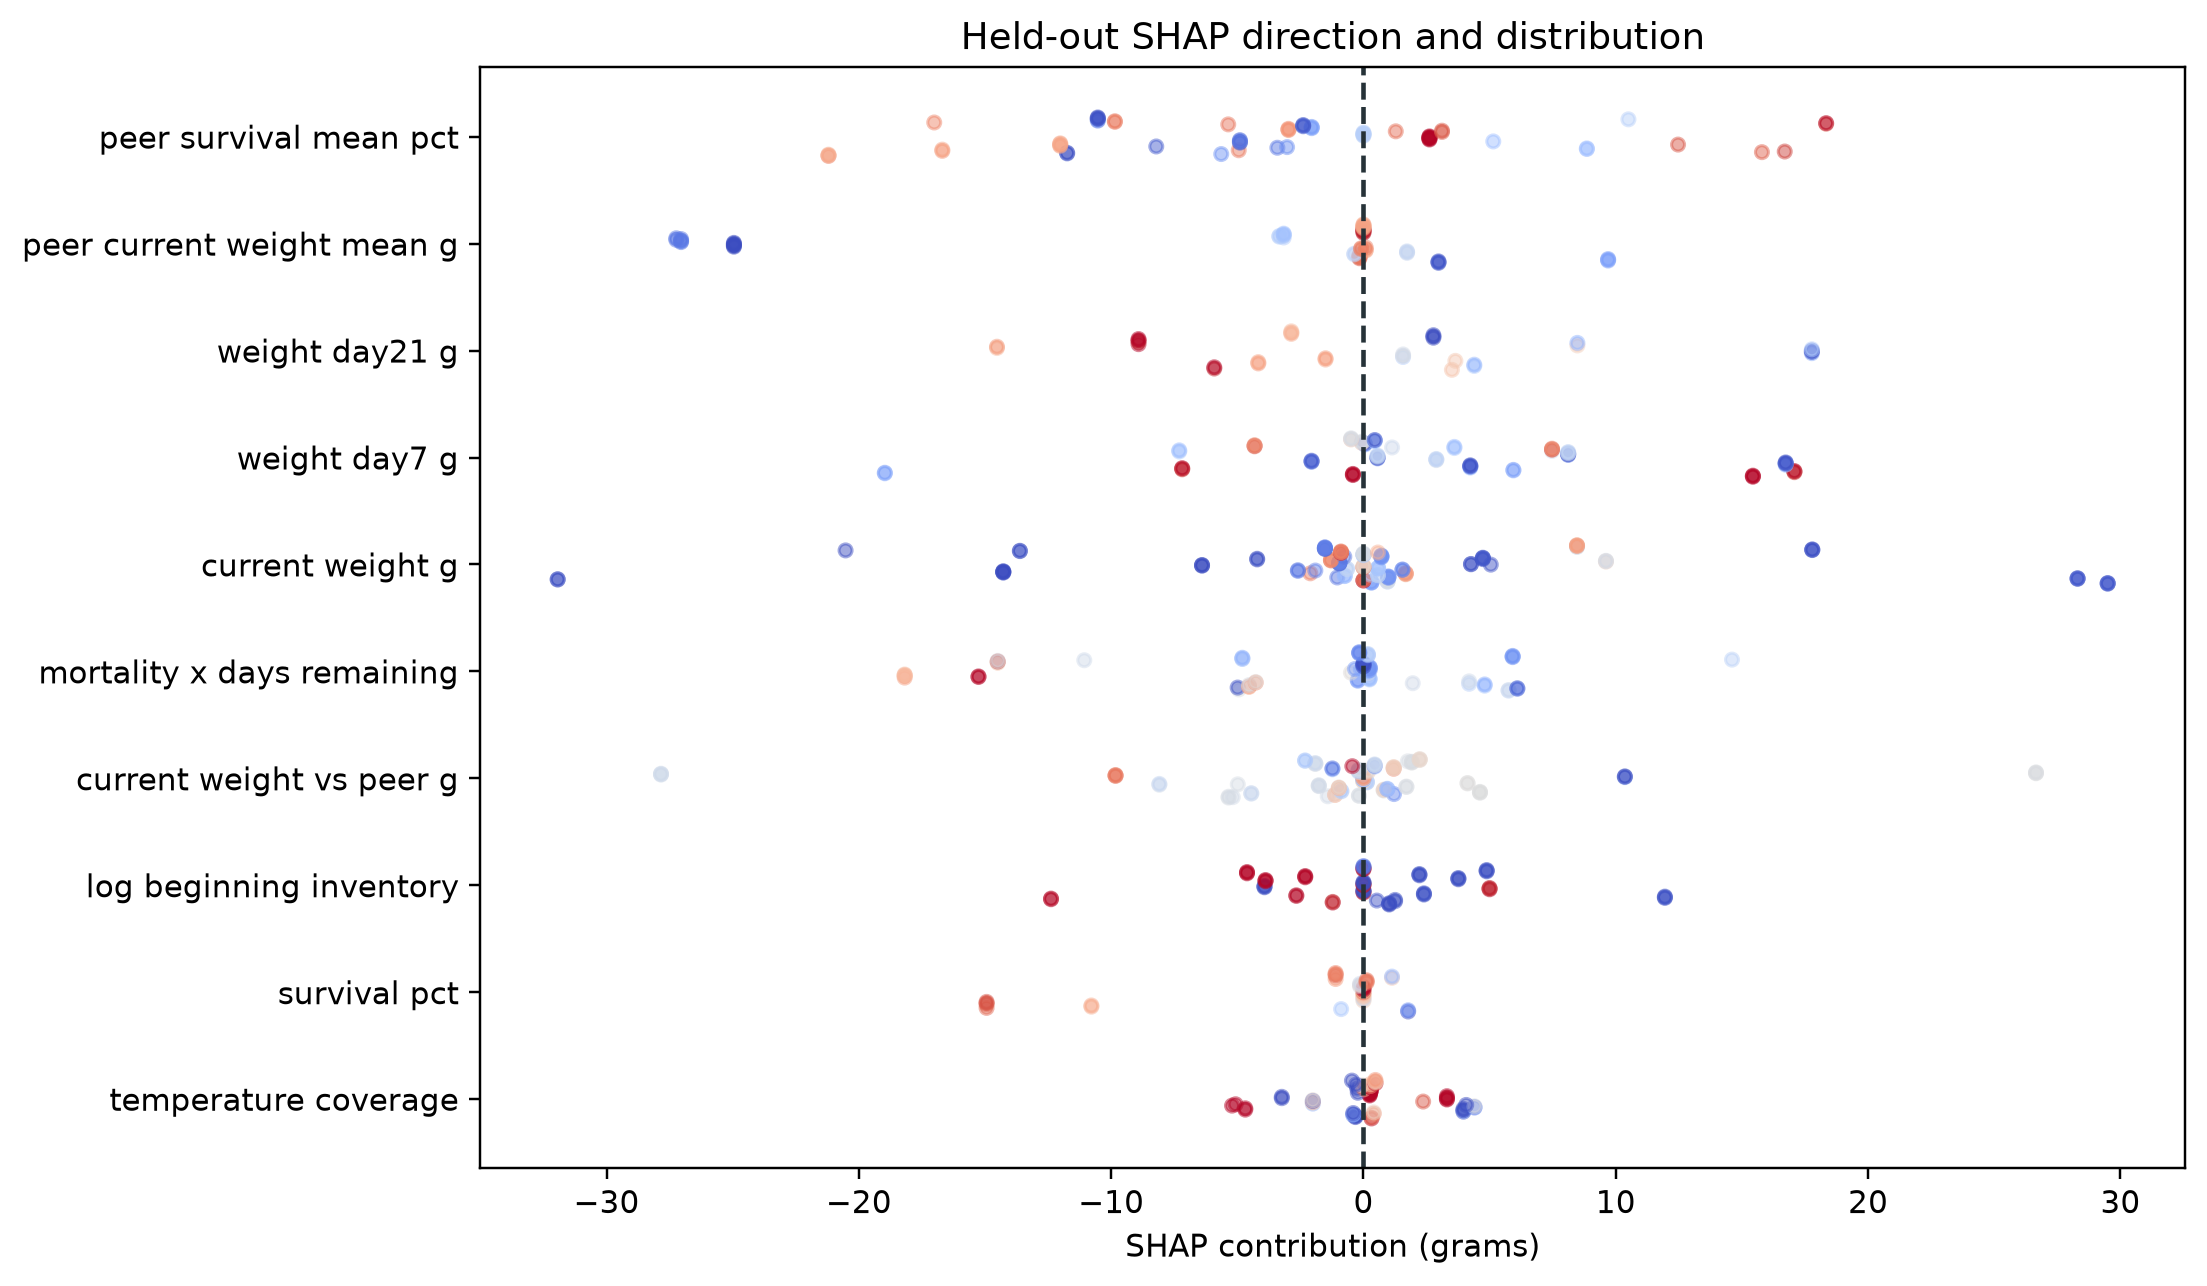

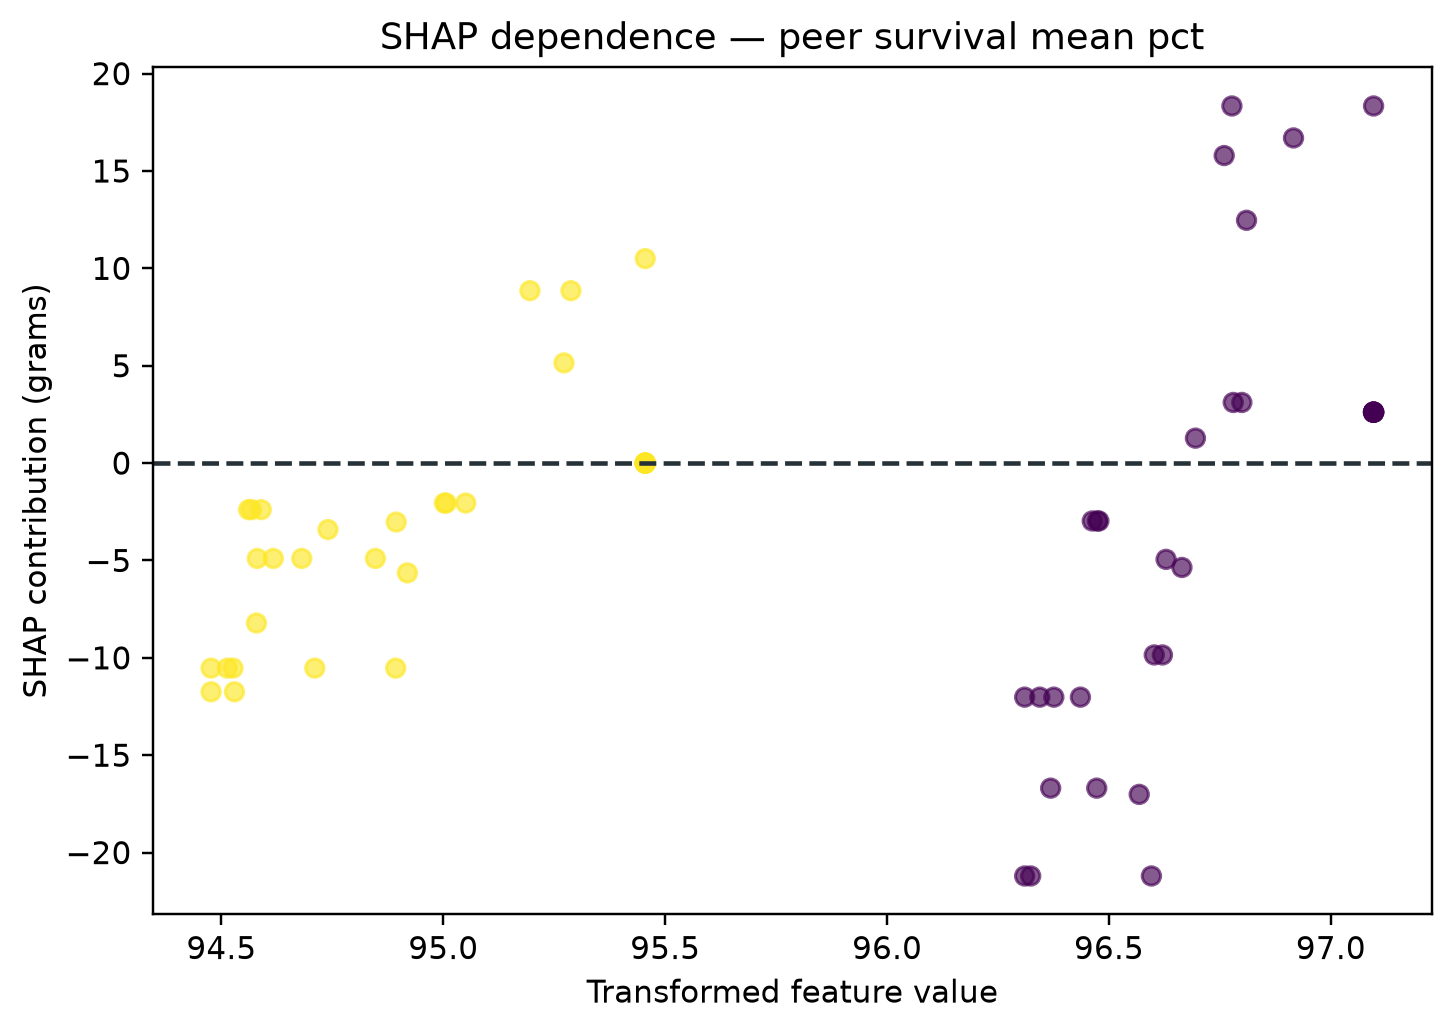

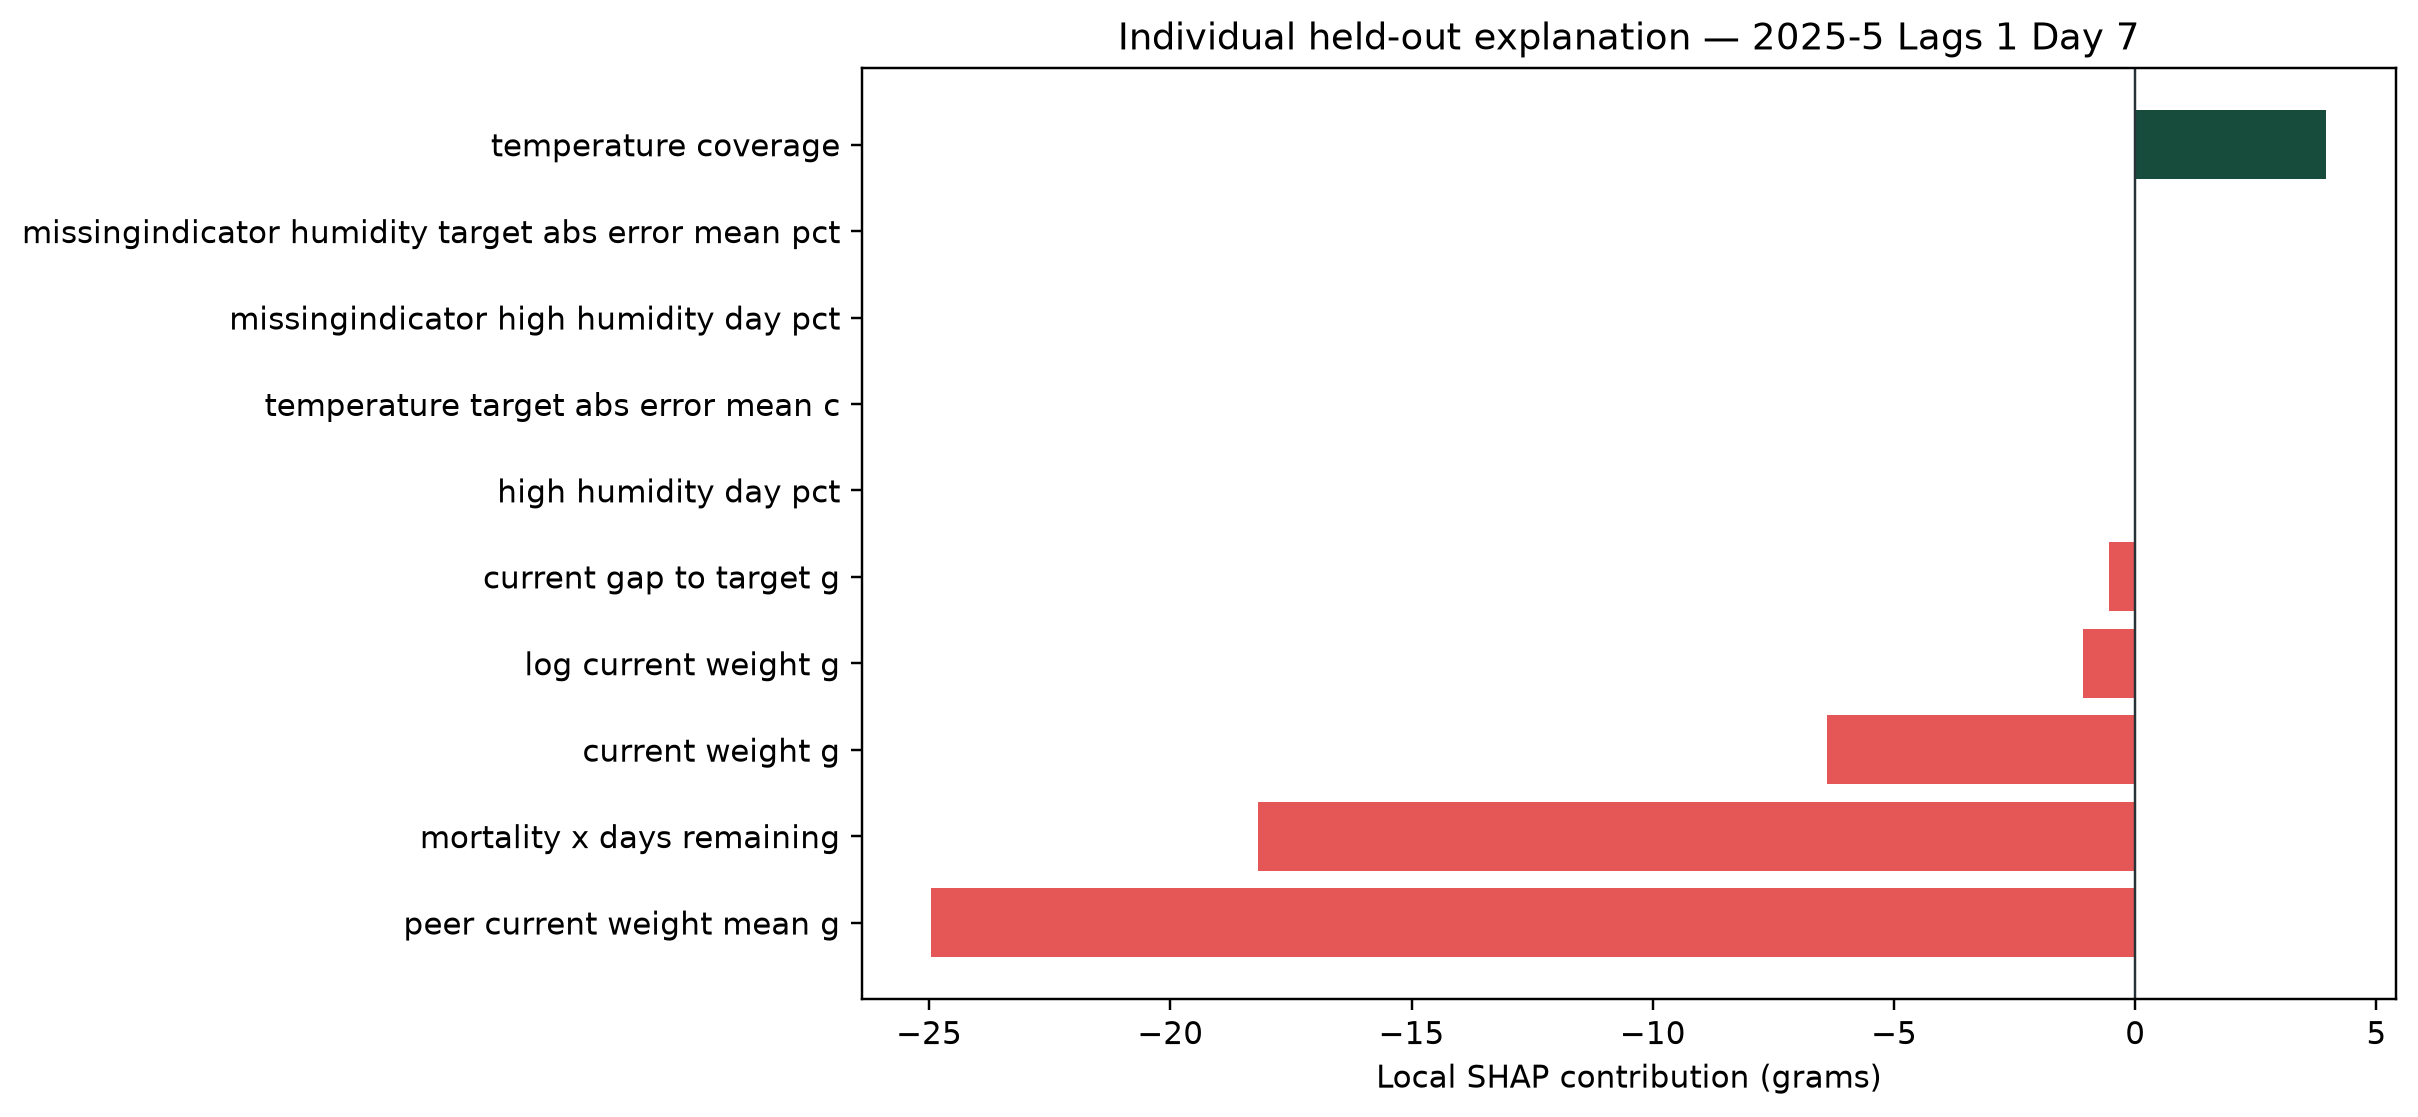

In [12]:
for outcome in ["recovery", "bodyweight"]:
    print("\n", outcome.upper())
    global_shap = pd.read_csv(OUTPUT_DIR / outcome / "held_out_shap_global.csv").sort_values("mean_abs_shap", ascending=False)
    display(global_shap.head(10).round(4))
    for name in ["shap_top10", "shap_beeswarm", "shap_dependence", "shap_local_waterfall"]:
        path = OUTPUT_DIR / "capstone_assets" / outcome / f"{name}.png"
        if path.exists(): display(Image(filename=str(path), width=900))

**SHAP warning:** these explanations apply to the compatible learned shadow model selected for explanation. A transparent baseline is explained by its explicit remaining-loss or remaining-gain calculation. SHAP and feature importance show predictive association, not causation, and must not be used to prescribe treatment.

## 10. Capstone defense and manuscript handoff

In [13]:
from IPython.display import Markdown
display(Markdown((OUTPUT_DIR / "CAPSTONE_DEFENSE_NOTES.md").read_text()))
print("Manuscript tables:", OUTPUT_DIR / "manuscript_tables")
print("Presentation figures (PNG + SVG):", OUTPUT_DIR / "capstone_assets")

# Project Canary capstone modeling evidence

## Executive conclusion

- Recovery champion: **age band remaining loss** — cycle-macro RMSE 3.09 percentage points, MAE 2.45, held-out R² 0.056.
- Day 35 bodyweight champion: **historical remaining gain** — cycle-macro RMSE 149.9 g, MAE 127.1 g, held-out R² 0.310.
- Validation holds out a complete harvest cycle. Results describe performance on a future production event, not interpolation within a known cycle.
- Daily forecasts are available from Day 7 through Day 34. Days 7, 14, 21 and 28 remain the principal validation anchors.
- Models remain capstone/shadow evidence and are not production-approved.

## How to defend the workflow

The pipeline begins from the authoritative workbook, preserves actually observed weights, aggregates environmental zones to one building-day, creates as-of features, fits all preprocessing inside training folds, and compares transparent baselines with regularized and tree-based models under nested cycle LOGO-CV. The one-standard-error rule prefers the simplest statistically competitive candidate.

## Trust and limitations

The analysis is defensible for a capstone because leakage controls, grouped validation, uncertainty and negative results are explicit. It is not production-ready because the data contain only 6 independent development harvest cycles, environmental measurement is incomplete, target-side outcomes are imbalanced and management predictors are missing. SHAP and feature importance show predictive association, not causation.

## Highest-value next data

Verified harvest endpoints; separate deaths/culls/removals; water and unit-confirmed feed; placement weight; strain and sex mix; stocking density; vaccination, medication and illness events; ventilation, CO₂ and ammonia; weight sample size, variability, scale and sampling time.


Manuscript tables: /Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest/manuscript_tables
Presentation figures (PNG + SVG): /Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest/capstone_assets


## 11. Gemini optimization prompt

# Gemini prompt — Project Canary Colab model optimization

You are assisting with Project Canary, a poultry decision-support capstone. Work as a senior machine-learning engineer and statistical reviewer. Inspect the executed notebook, its source audit, out-of-fold predictions, model registry, feature schemas, figures, and manifests before proposing changes.

## Outcomes

1. Predict final harvest recovery for each building-cycle: final recorded population divided by beginning inventory.
2. Predict actually observed average Day 35 bodyweight in grams.

The prediction is farm-wide but applied separately to each building using only that building's evidence available as of the prediction date.

## Non-negotiable validation rules

- Primary validation is nested Leave-One-Group-Out by complete harvest cycle. Never replace it with a random row split.
- Treat daily or checkpoint snapshots from one building-cycle as correlated observations, not independent flocks.
- Keep the locked newest cycle completely outside preprocessing, feature selection, tuning and champion selection.
- Learn imputation, scaling, clipping, feature selection, historical curves, peer context and hyperparameters inside training folds only.
- Never use population, mortality, environment, weight or peer evidence recorded after the review date.
- Never treat a target, interpolated or carried-forward bodyweight as a newly observed weight.
- Exclude exact building identity and Tags/Lags identity from primary models. Test them only as labelled sensitivity analyses.
- Exclude feed from primary models until its units are confirmed.
- Use cycle-macro RMSE as the main selection metric. Report pooled RMSE, MAE, held-out R², bias, worst-cycle error and checkpoint stability as supporting evidence.
- Do not optimize toward an arbitrary R² or report training R² as predictive evidence.
- Do not inspect or tune against the locked audit and then call it an audit.
- SHAP and feature importance describe predictive association, not causation.

## How to improve the notebook

Propose one falsifiable improvement at a time. For each proposal:

1. State the biological or statistical hypothesis.
2. Identify the exact new or changed features, target formulation, preprocessing or model family.
3. Explain why the feature is available at prediction time.
4. Add the experiment to the registry before running it.
5. Evaluate it on exactly the same outer cycle folds as the current baseline.
6. Keep all tuning inside inner cycle LOGO folds.
7. Save out-of-fold predictions and hyperparameters.
8. Compare cycle-macro RMSE, MAE, R², bias, worst-cycle RMSE, cycle wins, Day 14 performance and interval coverage.
9. Run a matched ablation to isolate whether the proposed change helped.
10. Report negative or unstable results honestly.

Useful areas to explore include mortality hazard/count formulations, biologically constrained remaining-loss targets, target-residual growth trajectories, state-space/Kalman updates, hierarchical growth curves, measurement-error-aware weights, environmental exposure between observations, conservative ensembles and normalized conformal intervals. Do not add deep or foundation models merely because they are fashionable; justify them against the number and density of independent time series.

## Model-selection standard

Use the one-standard-error rule: among candidates statistically competitive with the lowest cycle-macro RMSE, prefer the simplest and most stable. A learned challenger should remain shadow-only unless it materially beats the strongest transparent baseline, has positive unseen-cycle R², acceptable bias and worst-cycle error, stable checkpoint/temporal performance, and credible uncertainty coverage.

## Required response

Return:

1. A concise audit of the current pipeline.
2. The three highest-value improvement hypotheses, ranked by expected value and leakage risk.
3. Exact code changes in new, clearly labelled notebook cells; do not silently rewrite validated cells.
4. A matched experiment table before and after each change.
5. Updated manuscript-ready interpretation and presentation-ready charts.
6. A candid conclusion: improved, unchanged, or worse.
7. Any data limitation that cannot be solved by modeling.

Do not change outcome definitions, target thresholds, audit rules or deployment status without explicit team approval.

## 12. Download the complete evidence bundle

In [14]:
print(result["zip_path"])
if IN_COLAB:
    from google.colab import files
    files.download(result["zip_path"])

/Users/jourdan.go/Downloads/PROJECT CANARY/canary_app/outputs/colab_capstone_refresh_latest_EXPORT.zip


## Takeaways

Use the exported `CAPSTONE_DEFENSE_NOTES.md`, top-five tables, actual-versus-predicted charts, daily-learning curves and SHAP figures to supplement the manuscript and final presentation. Report limitations directly: few independent harvest cycles, structured missingness, target imbalance and absent management predictors. Failure of complex ML to beat a transparent baseline is a valid and defensible result.